<img src="logo.png" alt="Vegeta" width="240">

# FALCO — the tractor mountain aircraft (35)

**Falco-Zero** is NISUS+ (notebook 33) rebuilt as the frame study (notebook 34) said: a **large tractor propeller**
in the nose, a **simple tail** on one tube, more efficiency. NISUS+'s wing (2.4 m, crow flaps and ailerons, the
three-piece spar), its 24 Li-ion cells, its Jetson Orin, its mountain missions and its bird hunts stay; the twin-boom
pusher pod becomes **MERLIN's round fuselage** with a spinner, a cowl, a cylinder and a tail cone, the **FALCO-109**
marking raised on both sides, a **T-Motor AT5220-A KV220** turning an **APC 20x15E**, the pack re-connected **8S3P**
(the same cells, the same box: the low-KV motor needs the volts), a conventional tail on a **roll-wrapped 30/28 carbon
tube** in a keel socket with one dorsal fin. The landing is a belly landing with the **propeller parked horizontal**: a
20-inch blade straight down would be 150 mm in the meadow.

This notebook is the **first engineering approximation**, as NISUS+'s: every number is calculated, sourced or labelled
as an assumption; missing analyses say **NOT RUN**. NISUS+'s modules do the arithmetic through backward-compatible
`design=` / `sim=` seams; FALCO's modules hold what the tractor changes.

| part | what | where the code is |
|---|---|---|
| 1 | requirements, the frame study's verdict, the starting shape | `designs/falco.py` |
| 2 | CAD (Dedalus): parts, three-view, **the parked propeller's clearance**, crow, transport, exploded view, packaging | `falco.py`, `falco_drawings.py` |
| 3 | materials, construction, load paths | `falco_systems.py`, `falco_structure.py` |
| 4 | the atmosphere; mass, CG (the motor in the nose against the pack), inertia | `falco_systems.py` |
| 5 | electronics and their energy; the propeller's position sensor | `falco_systems.py` |
| 6 | propulsion: the sourced motor's fit, **the drive options (why 8S)**, **the propeller trade (why 20x15)**, the drive over altitude, the brake region, the pack | `falco_systems.py`, `falco_flight.py` |
| 7 | aerodynamics: lattice with one fin, crow, derivatives, the tractor's installation effects, CFD at altitude (NOT RUN) | `falco_flight.py`, `falco_cfd.py` |
| 8 | structure: load cases (+ gyroscopic, fin torsion, blade strike), hand checks, FEA: spar, joiner, **tail tube A/B and modes**, keel socket, firewall, tray | `falco_structure.py` |
| 9 | flight against altitude and **NISUS+ vs FALCO** (speed, acceleration, climb, descent, regeneration) | `falco_flight.py` |
| 10 | mission energy over the mountains | `falco_systems.py` |
| 11 | MuJoCo (Chiron) missions with the propeller parked for the landing, movies; 11b the bird hunt | `falco_robot.py`, `falco_controller.py`, `falco_scenario.py`, `falco_birds.py` |
| 12 | the gain, the parked landing's requirement, the first recommended build, what to refine | — |

Switches: `VEGETA_DEBUG=1` mocks FEA and CFD; `FALCO_QUICK=1` flies only the calm mission and one bird hunt, small
movies; `VEGETA_SKIP_OPENFOAM=1` skips the CFD (NOT RUN); `FALCO_FEA=0` skips the FEA (NOT RUN).

In [1]:
# DEBUG: test the notebook end to end before the full run (FEA and CFD mocked). On here or from the shell:
#   VEGETA_DEBUG=1 jupyter nbconvert --to notebook --execute 35_falco.ipynb --output 35_falco-run.ipynb
DEBUG = False
from vegeta import mock
DEBUG = mock.setup(DEBUG)

In [2]:
import json, math, os, sys, time
from dataclasses import replace
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Video, display
from vegeta import dedalus, talos, aeromant, boreas, cache
sys.path.insert(0, "designs")
import falco, falco_systems as fs, falco_flight as ff, falco_structure as fst, falco_cfd as fcfd, falco_drawings as fd
import falco_robot as fr, falco_controller as fc, falco_scenario as fsc, falco_birds as fb
import nisus_plus, nisus_plus_systems as nps, nisus_plus_flight as npf, frame_study as fstudy

pd.set_option("display.max_colwidth", 110); pd.set_option("display.width", 220)
ROOT = Path("_runs/falco"); ROOT.mkdir(parents=True, exist_ok=True)
OUT = Path("output") / "35_falco"; OUT.mkdir(parents=True, exist_ok=True)
for sub in ("cad", "drawings", "tables", "telemetry", "plots"):
    (OUT / sub).mkdir(exist_ok=True)
cache.notebook("35_falco")
QUICK = os.environ.get("FALCO_QUICK") == "1"
RUN_FEA = os.environ.get("FALCO_FEA", "1") != "0"
RUN_CFD = os.environ.get("VEGETA_SKIP_OPENFOAM") != "1"
G, RHO0 = fs.G, nps.RHO0
STATUS = {}
print(f"DEBUG {DEBUG} | QUICK {QUICK} | FEA {'on' if RUN_FEA else 'NOT RUN'} | CFD {'on' if RUN_CFD else 'NOT RUN'}")
def save_table(df, name):
    df.to_csv(OUT / "tables" / f"{name}.csv")
    return df

DEBUG False | QUICK False | FEA on | CFD NOT RUN


# Part 1 — requirements, the frame study's verdict, the starting shape

NISUS+'s requirements stand (the Alps up to 4500 m, climb ≥ 5 m/s at 4500 m, descent ≥ 10 m/s, a 20-min survey after
a 2800 m climb with 20 % reserve, the backpack), plus the frame study's three findings and the user's three decisions:

| from notebook 34 | what FALCO does |
|---|---|
| the 20-inch propeller does not fit between NISUS+'s booms (the spar fails, crow loses span) | the propeller goes to the **nose**: a tractor |
| a single tail is 213 g lighter, 3 x stiffer in bending, puts nothing into the wing; it must be **roll-wrapped** (torsion) | **one 30/28 roll-wrapped tube** in a keel socket, the fin on its end fitting |
| the 20-inch on a motor of the AT4125's class: −11 % mission energy, +20 % climb (an assumed motor) | a **real motor sourced** with its bench table (Part 6), its own gain measured against NISUS+ (Part 9) |

| decision | taken |
|---|---|
| the landing with a fixed nose propeller | **park it horizontal** with the ESC's brake and a position sensor before the flare; a keel; no gear (Part 2, 11) |
| the motor | the **AT5220 class, KV ~220**; the pack re-connected 8S3P when the 6S has not the volts (Part 6) |
| the fuselage | **MERLIN's tractor body** sized for the pack, the Orin and the sensors; the camera in the chin under the hub (image obstruction accepted: computer vision) |

The starting shape: NISUS+'s wing unchanged; the fuselage Ø130 x 830 mm, the spinner's tip 330 mm ahead of the wing's
leading edge (the motor in the nose against the pack under the wing: 28 % MAC); the tail at NISUS+'s arm (782 mm) with
its stabiliser (560 x 190) and one fin of 82 % of NISUS+'s two fins' area, on the centre line clear of the stabiliser's tips.

In [3]:
P = falco.resolve()
L = falco.Falco.layout(P)
DES = falco.Falco()
pt = pd.DataFrame([{"parameter": q.name, "value": P[q.name], "unit": q.units, "description": q.description} for q in falco.Falco.parameters if q.name in P]).set_index("parameter")
display(save_table(pt, "parameters"))
display(pd.Series({k: L[k] for k in ("S_ref", "AR", "mac", "V_h", "V_v", "l_t", "n_fins", "prop_x", "x_pod_end", "x_tube0", "tube_free_length", "prop_ground_margin",
                                     "prop_ground_margin_resting", "prop_ground_margin_parked", "prop_ground_margin_parked_resting", "resting_pitch_deg",
                                     "overall_length", "longest_piece_mm")}, name="layout").to_frame())

,value,unit,description
parameter,,,
part,aircraft,NaN,what to build
show_prop,False,NaN,aircraft: add the propeller disc (a thin cylinder) for pictures
span,2400.0,mm,
root_chord,300.0,mm,
tip_chord,200.0,mm,
...,...,...,...
tail_tube_id,28.0,mm,
tail_socket_length,200.0,mm,"the tube bonded in the keel's PETG socket, from the saddle to the tail cone's end"
stab_spar_od,12.0,mm,the stabiliser's carbon spar across the tube (a cantilever each side: 12/10)


,layout
S_ref,0.600000
AR,9.600000
mac,253.333333
V_h,0.547750
V_v,0.048769
l_t,782.500000
n_fins,1.000000
prop_x,-291.000000
x_pod_end,500.000000
x_tube0,300.000000


# Part 2 — CAD (Dedalus)

{'units': 'mm', 'valid': True, 'n_solids': 1, 'n_faces': 406, 'n_edges': 1083, 'bbox_min': [-330.0000001, -1200.0000001000005, -170.0000001], 'bbox_max': [1000.0000001, 1200.0000001000005, 316.0000001], 'dimensions': [1330.0000002, 2400.000000200001, 486.00000020000004], 'surface_area': 2022146.3488394278, 'volume': 23021511.107201148, 'center_of_mass': [170.83584862851055, 0.0008743338098049577, -3.5992683583264933]}


CAD parts (build, STEP):   0%|          | 0/12 [00:00<?, ?it/s]

crow pose: True 1 solid(s); 45 s


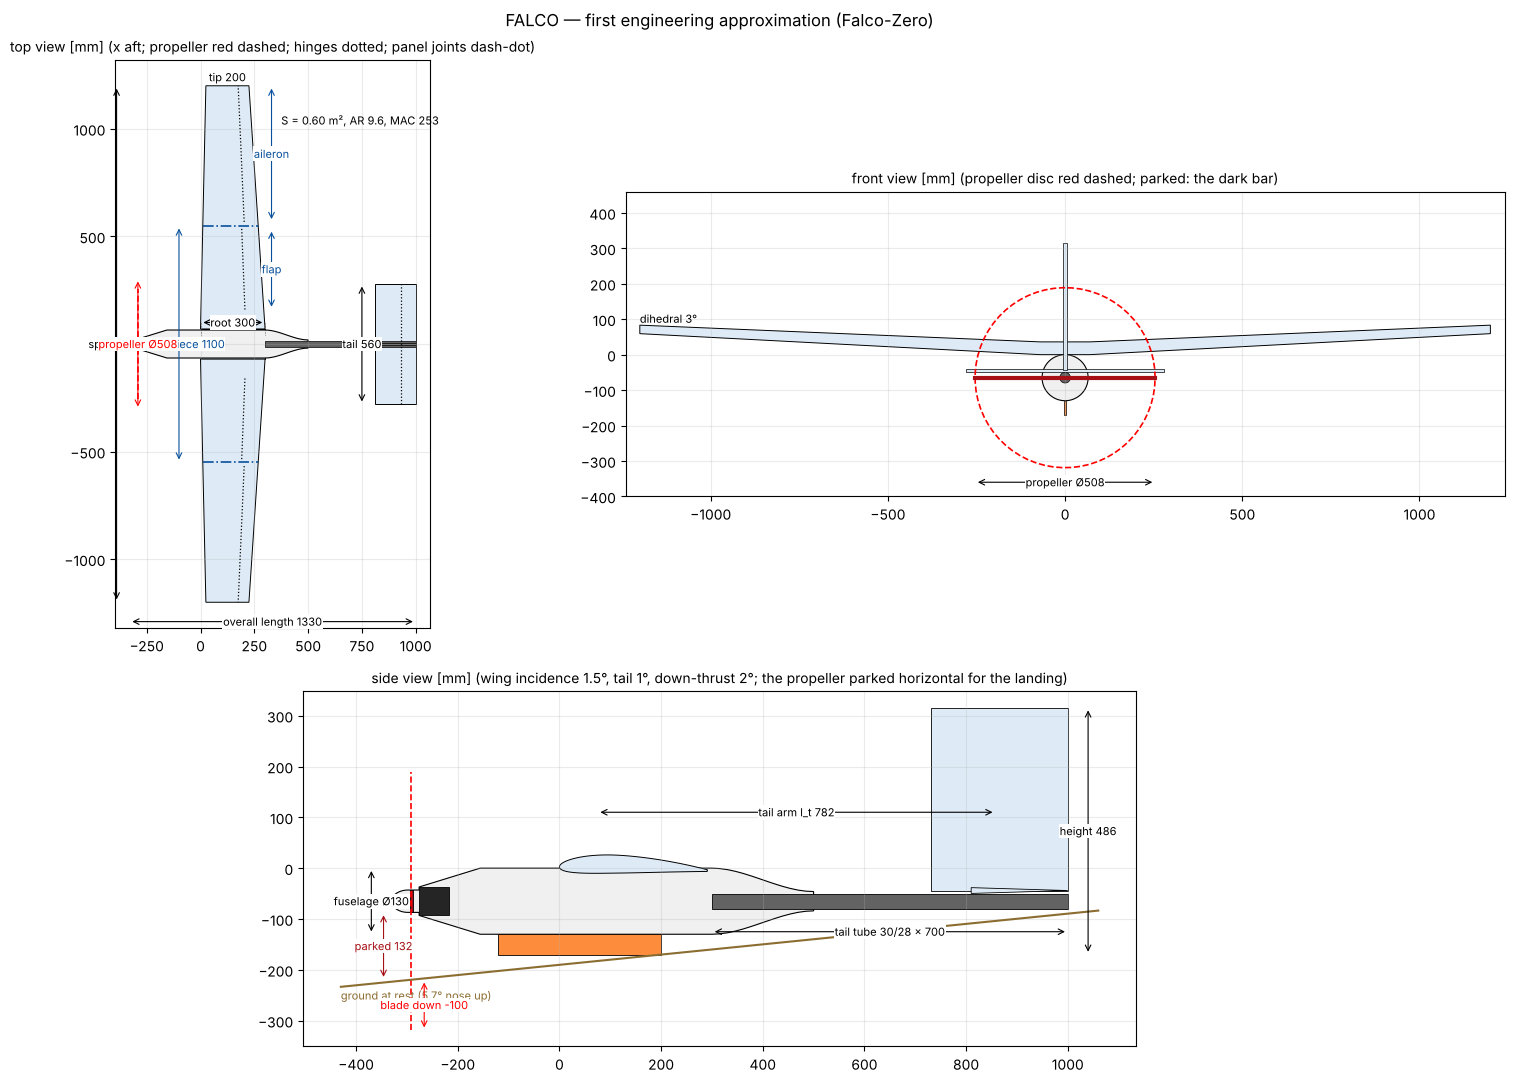

In [4]:
from tqdm.auto import tqdm
t0 = time.time()
GEO = DES.generate()
print(GEO.measure())
for part in tqdm(("aircraft", "wing", "pod", "nose", "tail_tube", "tail_socket", "tail_fitting", "tail", "motor_mount", "spar_joiner", "flap", "aileron"), desc="CAD parts (build, STEP)"):
    g = DES.generate(part=part)
    g.export_step(str(OUT / "cad" / f"falco_{part}.step"))
GEO.export_stl(str(OUT / "cad" / "falco_aircraft.stl"), tolerance=0.3)
CROW_GEO = DES.generate(flap_deg=55.0, aileron_deg=-25.0)
CROW_GEO.export_stl(str(OUT / "cad" / "falco_crow.stl"), tolerance=0.3)
print("crow pose:", CROW_GEO.measure()["valid"], CROW_GEO.measure()["n_solids"], "solid(s);", f"{time.time() - t0:.0f} s")
fig = fd.three_view(P); fig.savefig(OUT / "drawings" / "three_view.png", dpi=110); plt.show()

## The parked propeller

The blade-down clearance says why the propeller must be parked: a 20-inch blade straight down reaches 150 mm under the
keel's bottom. Parked horizontal, the lowest point is the spinner, 83 mm above the keel's bottom on a level touchdown and
more at the tail-low attitude of the rest (the keel's rear corner and the tail bumper carry the aircraft nose-up).

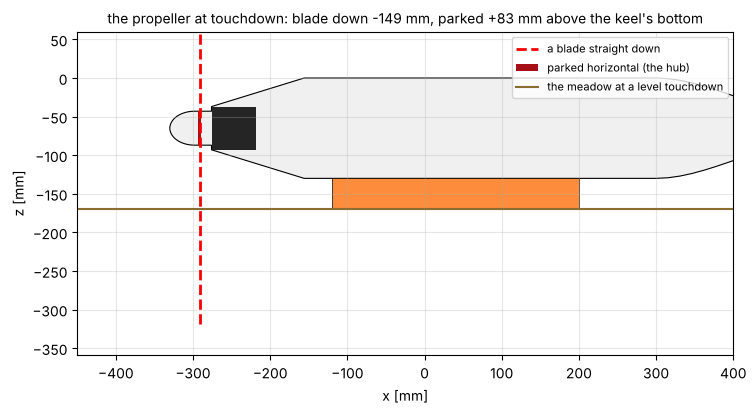

,blade straight down [mm],parked horizontal: hub and spinner [mm],verdict,parked verdict
body pitch +0° (nose up),-149.0,83.0,strike,clears
body pitch +4° (nose up),-114.386615,117.048245,strike,clears
body pitch +8° (nose up),-79.21595,150.526242,strike,clears
at rest (keel and tail bumper),-99.583226,132.416774,strike,clears


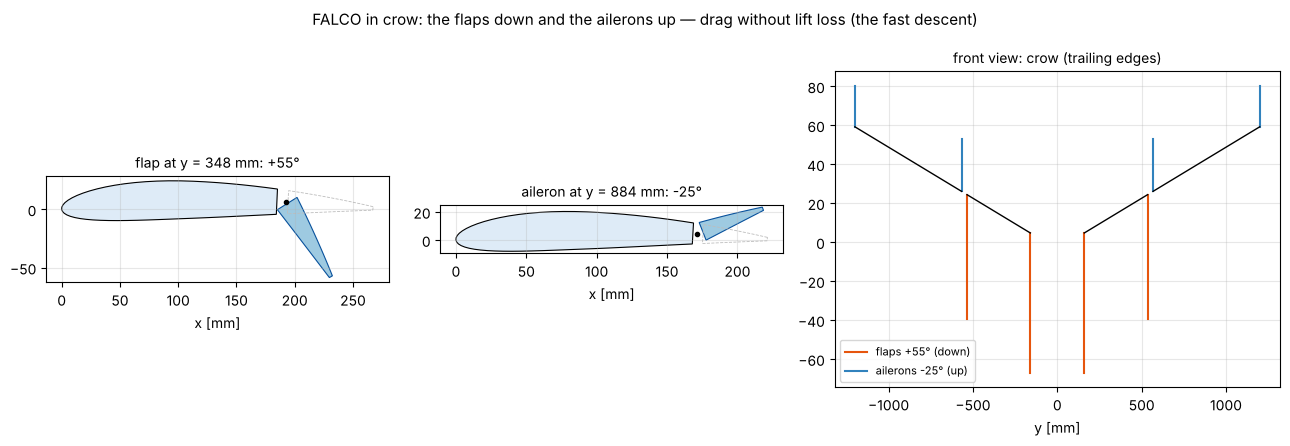

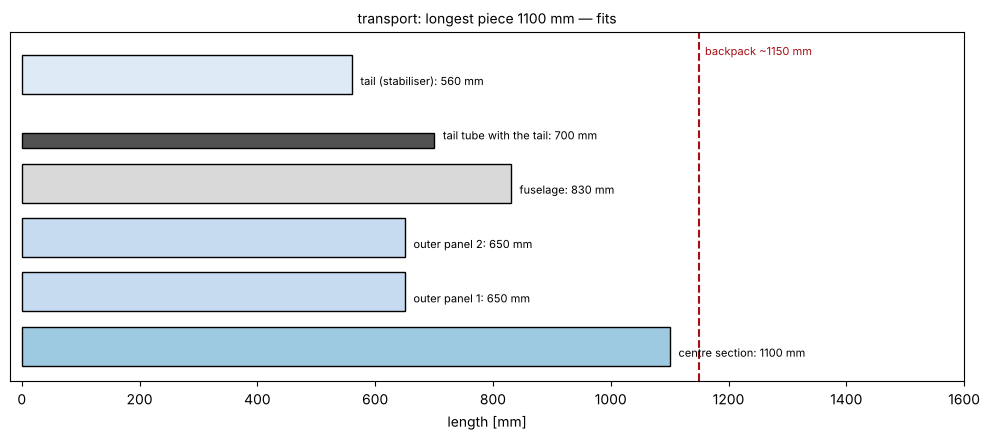

,transport
pieces_mm,"{'centre section': 1100.0, 'outer panel': 650.0, 'fuselage': 830.0, 'tail tube with the tail': 700.0, 'tai..."
longest_mm,1100.0
backpack_mm,1150.0
fits,True
note,"the centre section, two outer panels on the joiner, the fuselage with the motor and the spinner, the tail ..."


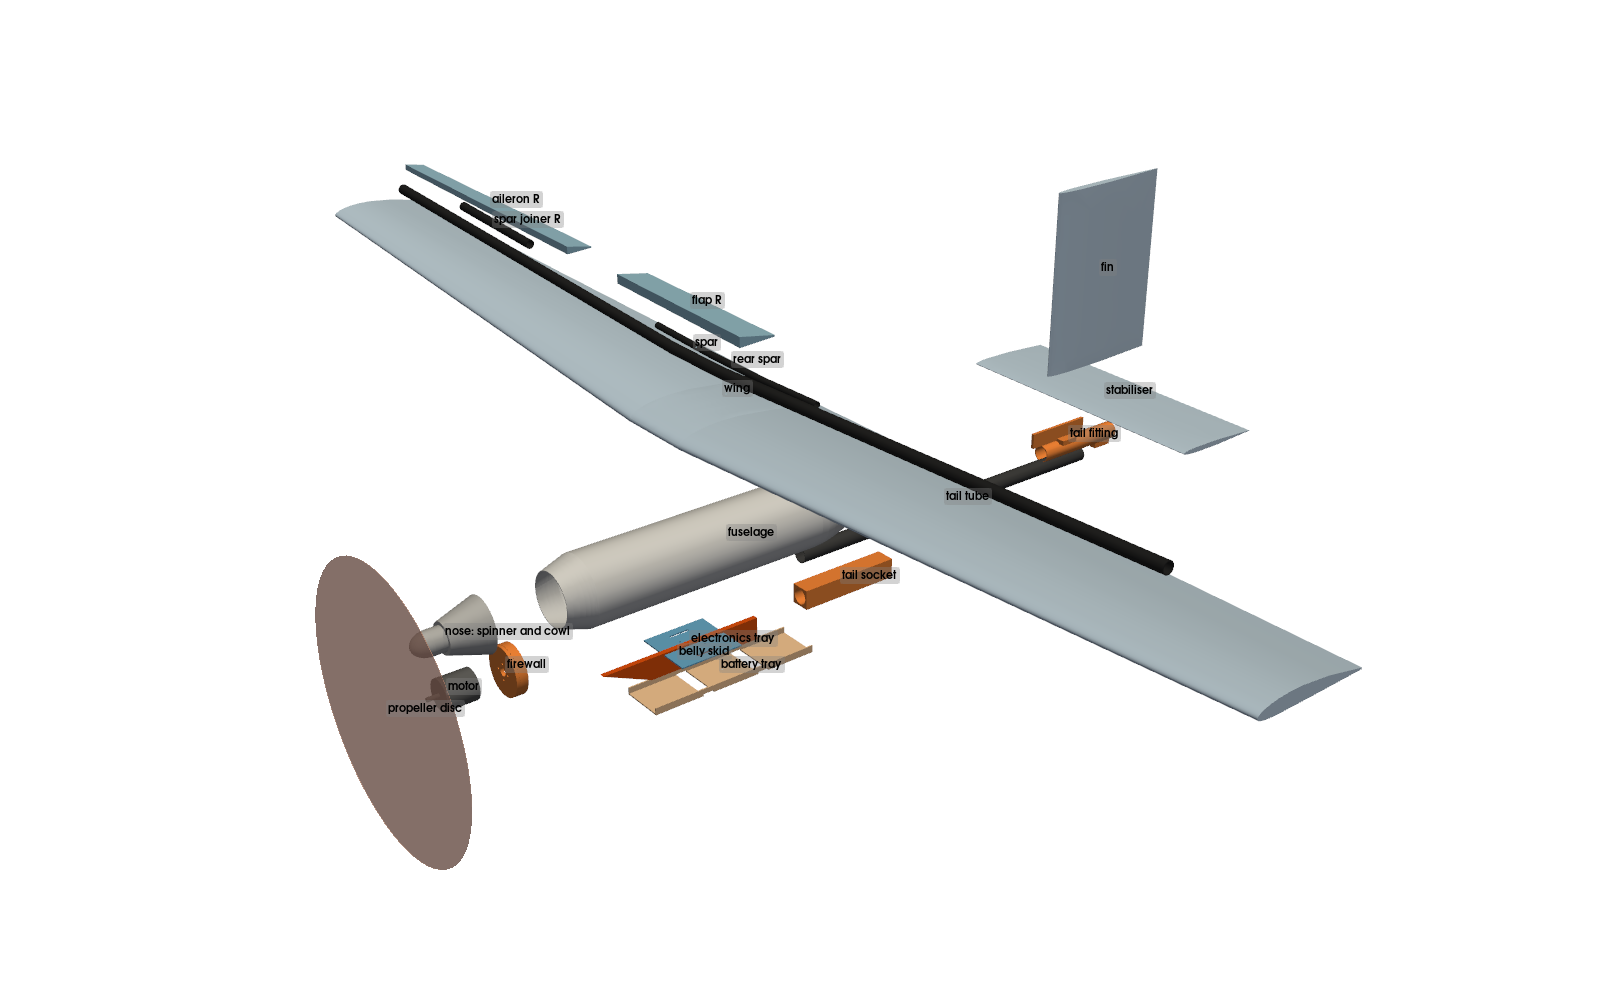

In [5]:
PC, fig = fd.park_clearance(P); fig.savefig(OUT / "drawings" / "park_clearance.png", dpi=110); plt.show()
display(save_table(PC, "park_clearance"))
fig = fd.crow_view(P); fig.savefig(OUT / "drawings" / "crow.png", dpi=110); plt.show()
fig = fd.transport_view(P); fig.savefig(OUT / "drawings" / "transport.png", dpi=110); plt.show()
display(pd.Series(falco.transport_check(P)).to_frame("transport"))
try:
    fd.exploded_png(OUT / "drawings" / "exploded.png", P)
    display(Image(str(OUT / "drawings" / "exploded.png"), width=900))
except Exception as e:
    print("the exploded view needs pyvista off screen (xvfb-run):", e)

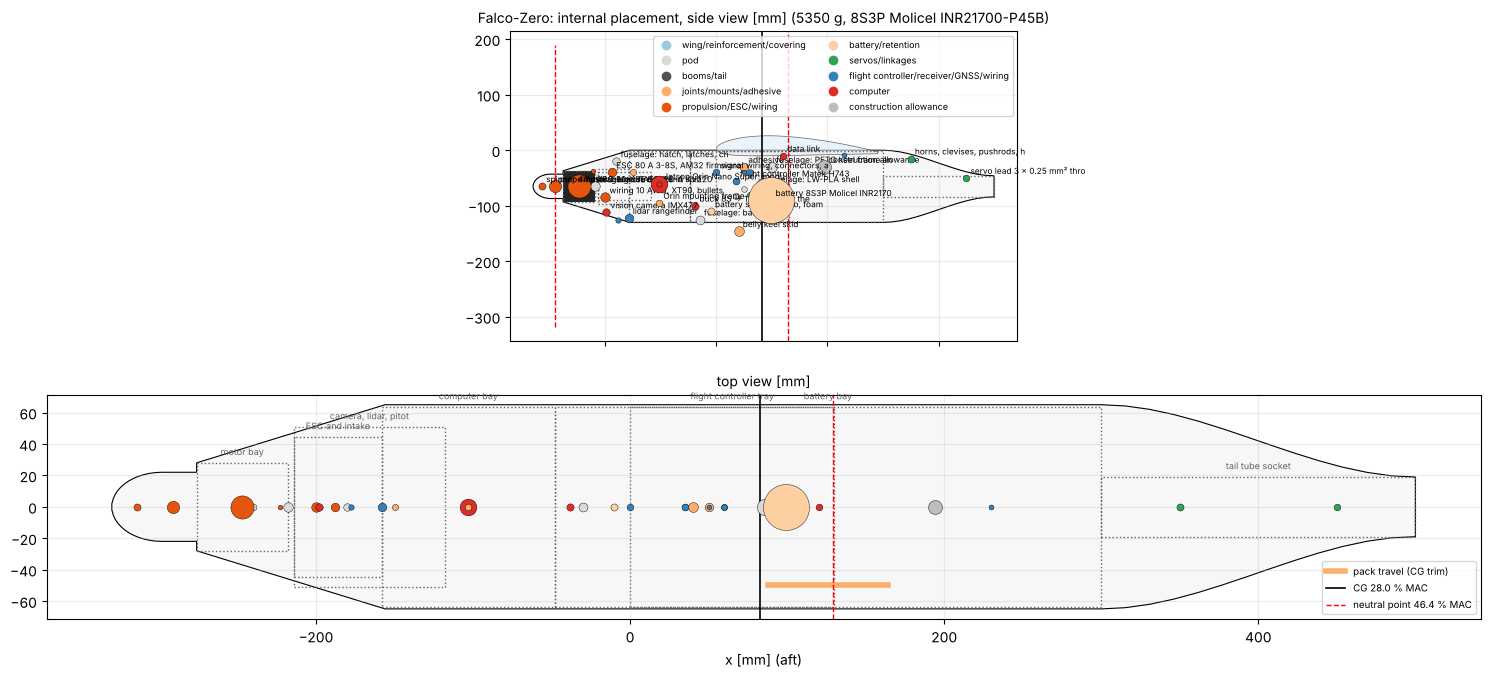

,x0 [mm],x1 [mm],width [mm],height [mm]
"motor bay (the bell in its cowl, the firewall behind)",-276.0,-218.0,56.0,56.0
ESC and intake (behind the firewall),-214.0,-158.0,88.9,63.5
"camera, lidar, pitot (chin)",-214.0,-118.0,101.6,50.8
computer bay (the Orin),-158.0,-48.0,127.0,127.0
battery bay,-48.0,300.0,127.0,127.0
flight controller tray (above the pack),0.0,130.0,127.0,127.0
tail tube socket (the keel),300.0,500.0,38.0,38.0


In [6]:
fig = fd.internal_layout(fs.DEFAULT_PACK, P); fig.savefig(OUT / "drawings" / "internal_layout.png", dpi=110); plt.show()
display(pd.DataFrame(falco.Falco.bays(P), index=["x0 [mm]", "x1 [mm]", "width [mm]", "height [mm]"]).T)

# Part 3 — materials, construction and load paths

NISUS+'s wing as built (an XPS core with the 2 mm balsa D-box, the 20/17 carbon spar in three pieces with joiners, the
rear carry-through tube now 12/10: no booms' moment to carry). The fuselage is an LW-PLA printed shell in two pieces
(the nose cowl with the spinner's shell to the joint behind the firewall; the body to the tail cone), a solid PETG
**firewall** with the 52xx bolt pattern bonded in the cowl, the PETG keel frame with the wing saddle and the **tail
tube's socket** (ribbed, 200 mm from the saddle to the tail cone's end), the roll-wrapped 30/28 tube, its end fitting
carrying the stabiliser's 12/10 spar, the fin's rod and the bumper, the elevator and rudder servos on it. Load paths:
the lift → the spar → the saddle; the tail's loads → the tube → the socket (a couple on its two ends); the thrust and
the brake's reverse thrust → the firewall → the cowl; the landing → the keel and the tail bumper.

In [7]:
display(pd.DataFrame(nps.MATERIALS).T)
display(pd.DataFrame(fs.structure_items(P), columns=["item", "group", "mass [g]", "x [mm]", "y [mm]", "z [mm]", "basis"]).set_index("item").round(1))

,rho,E,strength,source,strength_z,areal_g_m2
XPS foam 30,0.03,15.0,0.4,"extruded polystyrene 30 kg/m³ (Styrodur-class), catalogue values; assumption",NaN,NaN
carbon tube,1.55,120000.0,500.0,"pultruded unidirectional carbon tube, typical catalogue values (E 120-150 GPa along the fibres, G ~5 GPa, ...",NaN,NaN
PETG printed,1.25,2000.0,45.0,"PETG filament datasheet class (E 2.0 GPa, yield 45 MPa in the layer plane); the Z (layer-adhesion) strengt...",27.0,NaN
LW-PLA printed,0.55,900.0,10.0,colorFabb LW-PLA foamed at ~230 °C: 0.5-0.6 g/cm³ (vendor); E and strength of the foamed material assumed,NaN,NaN
TPU 95A,1.21,30.0,8.0,TPU 95A filament datasheet class,NaN,NaN
balsa,0.16,3000.0,15.0,"medium balsa, 160 kg/m³",NaN,NaN
covering film,NaN,NaN,NaN,"iron-on laminating film, 30-35 g/m² (vendor class)",NaN,32.0


,group,mass [g],x [mm],y [mm],z [mm],basis
item,,,,,,
wing: XPS core (25 % lightened),wing/reinforcement/covering,287.6,118.1,0.0,8.0,CAD volume x 30 kg/m³ x 0.75
wing: carbon spar tube 20/17 x 2000 (three pieces),wing/reinforcement/covering,270.5,90.0,0.0,6.0,CAD volume x 1.55 g/cm³
"wing: spar joiners 16.8/13.5 x 240 (carbon), 2 x",wing/reinforcement/covering,58.5,105.0,0.0,12.0,CAD volume x 1.55
"wing: tip rods 8/6 carbon, 2 x 200",wing/reinforcement/covering,13.6,120.0,0.0,50.0,tube section x length x 1.55
"wing: balsa D-box 2 mm (LE to spar, full span), TE strips, servo bays, joint ribs",wing/reinforcement/covering,146.0,48.0,0.0,8.0,D-box area x 2 mm x 0.16 g/cm³ + 25 g strips and ribs
wing: rear carry-through tube 12/10 x 440 (carbon),wing/reinforcement/covering,23.6,165.0,0.0,10.0,CAD volume x 1.55
wing: covering film,wing/reinforcement/covering,36.6,118.1,0.0,8.0,32 g/m² x wetted area
"wing: flap and aileron hinges, horns' hard points, tape",wing/reinforcement/covering,20.0,246.0,0.0,4.0,assumed
"wing: panel joint pins, latches, root ribs (plywood)",wing/reinforcement/covering,30.0,105.0,0.0,10.0,assumed


# Part 4 — the air, the mass, the centre of gravity, the inertia

The ISA with an offset as NISUS+'s. The mass table puts the 8S3P pack along its bay under the wing so the CG sits at
28 % MAC: with 600 g of motor, propeller and spinner 400 mm ahead of the wing, the nose had to be shortened to 330 mm
and the pack's bay moved aft to the tube's socket for the pack to reach it (the first placement sat at −2 % MAC).

In [8]:
display(save_table(fs.atmosphere_table(), "atmosphere"))
MT = {k: fs.mass_table(k, p=P) for k in ("8s3p-p45b", "6s4p-p45b")}
CI = {k: fs.cg_inertia(t, P) for k, t in MT.items()}
display(save_table(MT[fs.DEFAULT_PACK].round(1), "mass_table"))
display(MT[fs.DEFAULT_PACK].groupby("group")["mass [g]"].sum().round(0).to_frame())
print("pack placement:", MT[fs.DEFAULT_PACK].attrs["ballast_note"] or "inside its bay at the CG target", MT[fs.DEFAULT_PACK].attrs["battery_x_range"])
display(pd.DataFrame({k: {x: c[x] for x in ("mass_kg", "x_cg_frac_mac", "Ixx", "Iyy", "Izz", "Ixz", "wing_loading_N_m2")} for k, c in CI.items()}).T.round(3))
display(fs.component_table()[["group", "mass [g]", "kind", "availability", "source"]])

,T [°C],p [Pa],ρ [kg/m³],σ,ν [m²/s],a [m/s],density altitude [m]
0 m,15.00,101325.000000,1.225012,1.000010,0.000015,340.292287,-0.104299
1000 m,8.50,89874.521521,1.111653,0.907472,0.000016,336.432290,999.898054
1500 m,5.25,84555.935317,1.058077,0.863736,0.000016,334.485587,1499.899230
2000 m,2.00,79495.127849,1.006499,0.821632,0.000017,332.527488,1999.900407
3000 m,-4.50,70108.427324,0.909130,0.742147,0.000019,328.576286,2999.902760
4000 m,-11.00,61640.096069,0.819136,0.668682,0.000020,324.576987,3999.905112
4500 m,-14.25,57728.175369,0.776780,0.634106,0.000021,322.558743,4499.906289
5000 m,-17.50,54019.757684,0.736121,0.600915,0.000022,320.527792,4999.907465
6000 m,-24.00,47180.863673,0.659701,0.538532,0.000024,316.426785,5999.909818


,group,mass [g],x [mm],y [mm],z [mm],basis
item,,,,,,
wing: XPS core (25 % lightened),wing/reinforcement/covering,287.6,118.1,0.0,8.0,CAD volume x 30 kg/m³ x 0.75
wing: carbon spar tube 20/17 x 2000 (three pieces),wing/reinforcement/covering,270.5,90.0,0.0,6.0,CAD volume x 1.55 g/cm³
"wing: spar joiners 16.8/13.5 x 240 (carbon), 2 x",wing/reinforcement/covering,58.5,105.0,0.0,12.0,CAD volume x 1.55
"wing: tip rods 8/6 carbon, 2 x 200",wing/reinforcement/covering,13.6,120.0,0.0,50.0,tube section x length x 1.55
"wing: balsa D-box 2 mm (LE to spar, full span), TE strips, servo bays, joint ribs",wing/reinforcement/covering,146.0,48.0,0.0,8.0,D-box area x 2 mm x 0.16 g/cm³ + 25 g strips and ribs
wing: rear carry-through tube 12/10 x 440 (carbon),wing/reinforcement/covering,23.6,165.0,0.0,10.0,CAD volume x 1.55
wing: covering film,wing/reinforcement/covering,36.6,118.1,0.0,8.0,32 g/m² x wetted area
"wing: flap and aileron hinges, horns' hard points, tape",wing/reinforcement/covering,20.0,246.0,0.0,4.0,assumed
"wing: panel joint pins, latches, root ribs (plywood)",wing/reinforcement/covering,30.0,105.0,0.0,10.0,assumed


,mass [g]
group,
battery/retention,1844.0
booms/tail,382.0
computer,332.0
construction allowance,154.0
flight controller/receiver/GNSS/wiring,143.0
joints/mounts/adhesive,174.0
pod,509.0
propulsion/ESC/wiring,718.0
servos/linkages,207.0


pack placement: inside its bay at the CG target (88.0, 164.0)


,mass_kg,x_cg_frac_mac,Ixx,Iyy,Izz,Ixz,wing_loading_N_m2
8s3p-p45b,5.35,0.28,0.485,0.334,0.802,0.009,87.467
6s4p-p45b,5.35,0.28,0.485,0.334,0.802,0.009,87.467


,group,mass [g],kind,availability,source
item,,,,,
motor T-Motor AT5220-A KV220 (long shaft),propulsion/ESC/wiring,450.0,sourced,not confirmed,"450 g with cable, Φ60 x 112.3 mm, 36 mΩ, 24N28P, 6-12S, idle 1.8 A at 10 V, 70 A / 2700 W for 180 s (T-Mot..."
"propeller APC 20x15E thin electric (fixed: it brakes, regenerates and parks)",propulsion/ESC/wiring,118.0,sourced,not confirmed,"117.93 g (Motion RC, LP20015E); the 20x13E is 117.08 g (the reverse LP20013EP listing); 118 g taken; 6.35 ..."
"spinner 44 mm (aluminium backplate, printed cone) with the hub's parking magnet",propulsion/ESC/wiring,30.0,assumed,not confirmed,"estimate: a 44 mm two-blade spinner with an aluminium backplate and the 8 mm shaft adapter, 25 g, plus a 5..."
"propeller position sensor (Hall sensor on the firewall, magnet in the hub)",propulsion/ESC/wiring,5.0,assumed,not confirmed,assumed: a latching Hall sensor and a 5 mm magnet on the spinner's backplate: one pulse per turn says wher...
"ESC 80 A 3-8S, AM32 firmware (active freewheeling, brake, bidirectional)",propulsion/ESC/wiring,50.0,assumed,not confirmed,"80 A continuous / 100 A peak, 3-8S AM32 class (as NISUS+'s: a single-motor 80 A AM32 ESC assumed, 50 g wit..."
"wiring 10 AWG, XT90, bullets, leads, capacitor",propulsion/ESC/wiring,65.0,assumed,not confirmed,"estimate: 10 AWG battery lead 2 x 350 mm (the pack under the wing, the ESC behind the firewall), XT90 pair..."
"battery straps, velcro, foam, insulating sleeve",battery/retention,30.0,assumed,not confirmed,"estimate: two 25 mm straps with buckles, velcro pads, 5 mm closed-cell foam sleeve (keeps the pack warm at..."
servo 22 g metal gear (flap L),servos/linkages,22.0,assumed,not confirmed,"assumed: a 20-25 g metal-gear wing servo, 6-8 kg·cm at 7.4 V, 0.10 s/60° (KST / Emax class); not researched"
servo 22 g metal gear (flap R),servos/linkages,22.0,assumed,not confirmed,"assumed: a 20-25 g metal-gear wing servo, 6-8 kg·cm at 7.4 V, 0.10 s/60° (KST / Emax class); not researched"


# Part 5 — electronics and their energy

NISUS+'s loads on an 8S bus (every device rated to 36 V: the ESC's 3-8S rating, the flight controller's 6-36 V, a 36 V
buck and BEC), plus the **propeller's position sensor** (a Hall sensor on the firewall, a magnet on the spinner's
backplate: one pulse per turn) that the parking routine reads.

In [9]:
display(save_table(fs.electrical_loads().round(2), "electrical_loads"))
display(fs.phase_power().round(1))
display(fs.servo_check(P).round(2))

,supply,V,idle [W],typical [W],peak [W],duty (survey),regulator eff.,battery-side average [W],battery-side peak [W],source
load,,,,,,,,,,
"ESC 80 A 3-8S, AM32 firmware (active freewheeling, brake)",battery,21.6,0.50,0.50,0.50,1.0,1.00,0.50,0.50,"assumed: 80 A continuous / 100 A peak, 3-8S AM32 class (Pilotix listing — a 4-in-1 board: a single-"
servo 22 g metal gear (flap L),servo,7.4,0.20,1.00,12.00,0.6,0.85,0.80,14.12,"assumed: assumed: a 20-25 g metal-gear wing servo, 6-8 kg·cm at 7.4 V, 0.10 s/60° (KST / Emax class"
servo 22 g metal gear (flap R),servo,7.4,0.20,1.00,12.00,0.6,0.85,0.80,14.12,"assumed: assumed: a 20-25 g metal-gear wing servo, 6-8 kg·cm at 7.4 V, 0.10 s/60° (KST / Emax class"
servo 22 g metal gear (aileron L),servo,7.4,0.20,1.00,12.00,0.6,0.85,0.80,14.12,"assumed: assumed: a 20-25 g metal-gear wing servo, 6-8 kg·cm at 7.4 V, 0.10 s/60° (KST / Emax class"
servo 22 g metal gear (aileron R),servo,7.4,0.20,1.00,12.00,0.6,0.85,0.80,14.12,"assumed: assumed: a 20-25 g metal-gear wing servo, 6-8 kg·cm at 7.4 V, 0.10 s/60° (KST / Emax class"
servo 22 g metal gear (elevator),servo,7.4,0.20,1.00,12.00,0.6,0.85,0.80,14.12,"assumed: assumed: a 20-25 g metal-gear wing servo, 6-8 kg·cm at 7.4 V, 0.10 s/60° (KST / Emax class"
"servo 22 g metal gear (rudders, torque rod)",servo,7.4,0.20,1.00,12.00,0.6,0.85,0.80,14.12,"assumed: assumed: a 20-25 g metal-gear wing servo, 6-8 kg·cm at 7.4 V, 0.10 s/60° (KST / Emax class"
flight controller Matek H743-WING (ArduPilot),battery,21.6,1.50,1.80,2.50,1.0,1.00,1.80,2.50,"assumed: assumed: the H743-WING class (6-36 V input, 5 V/9 V BECs, current sensor, ArduPilot Plane"
GNSS + compass Matek M10Q-5883,5V,5.3,0.25,0.25,0.35,1.0,0.85,0.29,0.41,sourced: as NISUS's (nisus_component_sources.md)


,electronics battery-side [W]
prelaunch,26.9
launch+climb,33.6
transit,31.9
survey,33.6
return,31.9
descent,34.7
approach+landing,35.3


,area [cm²],EAS [m/s],deflection [deg],hinge moment [N·cm],servo torque needed [kg·cm],servo [kg·cm],safety factor
aileron (each) at V_NE,358.11,40.0,25.0,38.28,3.90,6.0,1.54
flap (each) in crow 55° at V_FE,309.87,22.0,55.0,19.82,2.02,6.0,2.97
elevator at V_NE,372.40,40.0,25.0,42.36,4.32,6.0,1.39
rudder at V_NE,340.20,40.0,25.0,54.99,5.61,6.0,1.07


# Part 6 — propulsion: the sourced motor, why 8S, why 20x15

The **T-Motor AT5220-A KV220** (52 mm stator, 450 g, 6-12S, 70 A / 2700 W for 180 s) is the one motor of the class
whose maker publishes a full bench table with the rpm: APC 18x8 at 12S from 40 to 100 % throttle (43.33 V, 48.86 A,
8141 rpm, 2.037 N m, 8185 gf at 100 %). The model is fitted to the 100 % point (R with the ESC and the wires, as NISUS+'s
fit); kt (I − I0) against the published torque checks the datasheet's I0; the 70 % row checks the propeller's torque
calibration. The calibration ratios are carried from the 18x8 to the 20-inch planform — assumed.

**Why 8S.** On the 6S pack the KV220 has the volts for ~3900 rpm on a 20x13: 0.5 kW shaft, static T/W below 0.7. The
KV380 variant on 6S would run the 20x13 past the ESC's 80 A and sits at that limit when held back. The same 24 cells
re-connected **8S3P** (the same box, the same 388 Wh) give the frame study's 20-inch point (~4800 rpm, ~1.1 kW shaft)
at ~50 A within every limit.

**Why 20x15.** The frame study's 20x13 cruises at 18 m/s EAS near its zero-thrust advance ratio: the blades sit at
their zero-lift angle and the profile drag is all that is left (67 % efficiency, more cruise power than NISUS+'s
15x8). The 20x15 cruises at 73 % and climbs 15 % faster for the same static current class; its pitch speed at the
static rpm (31 m/s) covers the dash.

In [10]:
AF0 = {"mass_kg": CI[fs.DEFAULT_PACK]["mass_kg"], "cd0": falco.drag_buildup(P, 20.0)["cd0"], "AR": L["AR"], "oswald": 0.9, "S": L["S_ref"]}
REQ = fs.requirements(AF0["mass_kg"], AF0["cd0"], AF0["AR"], AF0["oswald"], AF0["S"])
display(save_table(REQ.round(2), "requirements"))
MOTOR, FIT = fs.motor_model()
display(pd.Series({k: v for k, v in FIT.items() if not isinstance(v, (dict, str))}, name="motor fit (AT5220-A KV220 on the 18x8 at 12S)").to_frame())
display(pd.DataFrame(fs.PUBLISHED_STATIC["rows"], columns=["throttle", "V", "A", "W", "rpm", "N m", "gf"]).set_index("throttle"))
DOPT = fs.drive_options(P, progress=True)
display(save_table(DOPT, "drive_options"))
print("selected:", DOPT.attrs["selected"], "—", DOPT.attrs["why"])

,altitude [m],TAS [m/s],thrust [N],T/W,aero power T·V [W],shaft power [W],electrical [W]
cruise 20 m/s TAS at 0 m,0.0,20.00,4.29,0.08,85.86,143.11,186.34
cruise 20 m/s TAS at 3000 m,3000.0,20.00,3.60,0.07,72.08,120.13,156.42
cruise 20 m/s TAS at 4500 m,4500.0,20.00,3.37,0.06,67.46,112.44,146.41
climb 8 m/s at 0 m (16 m/s EAS),0.0,16.00,29.62,0.56,473.99,789.99,1028.63
climb 5 m/s at 4500 m (18 m/s EAS),4500.0,22.60,15.38,0.29,347.63,579.39,754.41
dash 30 m/s EAS at 3000 m,3000.0,34.82,8.41,0.16,292.98,488.31,635.82
launch: static T/W ≥ 0.7,3000.0,0.00,36.74,0.70,0.00,NaN,NaN


,motor fit (AT5220-A KV220 on the 18x8 at 12S)
rpm_at_point,8141.000000
resistance_ohm,0.129461
no_load_a,1.800000
kt,0.043406
bemt_thrust_n,72.583183
published_thrust_n,80.294850
thrust_correction,1.106246
bemt_torque_nm,1.867543
motor_torque_nm,2.042681
published_torque_nm,2.037000


,V,A,W,rpm,N m,gf
throttle,,,,,,
0.40,44.30,4.27,189.20,3585,0.383,1469
0.45,44.27,5.57,246.66,3980,0.460,1818
0.50,44.20,8.59,379.74,4592,0.600,2446
0.55,44.13,11.17,492.86,5055,0.745,3009
0.60,44.08,13.86,611.06,5473,0.857,3502
0.65,44.01,16.93,745.00,5839,0.991,4080
0.70,43.93,20.49,900.27,6232,1.131,4668
0.75,43.84,24.92,1092.62,6656,1.326,5323
0.80,43.75,29.00,1268.80,6969,1.466,5924


drive options (motor x pack x propeller: BEMT static points):   0%|          | 0/8 [00:00<?, ?it/s]

,motor,pack,V nominal,propeller,"rpm (static, full throttle)",motor current [A],shaft power [W],motor efficiency,static thrust [N],T/W ≥ 0.7 (37 N),pitch speed [m/s],limit,published
AT5220-A KV220 / 6S4P / 20x13,AT5220-A KV220,6S4P Molicel INR21700-P45B,21.6,APC 20x13E,3880.391208,30.602763,508.027227,0.768551,36.44952,False,21.355086,within the motor's and the ESC's limits,the KV220's 18x8 table
AT5220-A KV220 / 6S4P / 20x15,AT5220-A KV220,6S4P Molicel INR21700-P45B,21.6,APC 20x15E,3809.216988,33.101738,541.977774,0.758013,36.269841,False,24.188528,within the motor's and the ESC's limits,the KV220's 18x8 table
AT5220-A KV220 / 6S4P / 22x12,AT5220-A KV220,6S4P Molicel INR21700-P45B,21.6,APC 22x12E,3711.900854,36.518572,585.781344,0.742622,43.977411,True,18.856456,within the motor's and the ESC's limits,the KV220's 18x8 table
AT5220-A KV220 / 8S3P / 20x13,AT5220-A KV220,8S3P Molicel INR21700-P45B,28.8,APC 20x13E,4949.880361,48.667581,1054.495083,0.752337,59.310311,True,27.240842,within the motor's and the ESC's limits,the KV220's 18x8 table
AT5220-A KV220 / 8S3P / 20x15,AT5220-A KV220,8S3P Molicel INR21700-P45B,28.8,APC 20x15E,4843.412141,52.405751,1114.111399,0.738171,58.637721,True,30.755667,within the motor's and the ESC's limits,the KV220's 18x8 table
AT5220-A KV220 / 8S3P / 22x12,AT5220-A KV220,8S3P Molicel INR21700-P45B,28.8,APC 22x12E,4699.630491,57.45402,1188.87877,0.718497,70.495979,True,23.874123,within the motor's and the ESC's limits,the KV220's 18x8 table
AT5220-A KV380 / 6S4P / 20x13,AT5220-A KV380,6S4P Molicel INR21700-P45B,21.6,APC 20x13E,4796.061811,80.0,959.212362,0.759553,55.681424,True,26.394327,throttle held to 80 A (the motor's 100 A / the ESC's 80 A),no table: R scaled from the datasheet's 11 mΩ (assumed)
AT5220-A KV380 / 6S4P / 18x10,AT5220-A KV380,6S4P Molicel INR21700-P45B,21.6,APC 18x10E,6822.729278,80.0,1364.545856,0.807647,67.468016,True,28.882887,throttle held to 80 A (the motor's 100 A / the ESC's 80 A),no table: R scaled from the datasheet's 11 mΩ (assumed)


selected: AT5220-A KV220 / 8S3P / 20x15 — the KV220 on 6S has the volts for ~3900 rpm only (~0.5 kW shaft, T/W < 0.7: no climb margin at 4500 m); the KV380 on 6S would run the 20x13 past the ESC's 80 A and sits at that limit when held (3/4 of its power, the ESC at its edge); the KV220 on 8S3P — the same 24 cells re-connected, the same box — gives the frame study's 20-inch point at ~50 A within every limit; the pitch is the propeller trade's (falco_flight.propeller_trade: the 20x15 over the 20x13 for the cruise). The fallback that keeps the 6S4P is the KV380 with an 18x10 (full throttle at the ESC's limit, the smaller disc: the frame study's 18-inch gain, not the 20-inch one)


In [11]:
A = ff.aero(P)
TRADE = ff.propeller_trade(p=P, progress=True)
display(save_table(TRADE.round(2), "propeller_trade"))
print("selected:", TRADE.attrs["selected"])
DR = fs.drive(rebuild=not Path(fs.PROPULSION_JSON).exists())
display(save_table(fs.drive_table(DR).round(2), "drive_vs_altitude"))

propeller trade (a Boreas map, the envelope and the mission per propeller):   0%|          | 0/7 [00:00<?, ?it…

,static thrust [N],static current [A],static rpm,pitch speed at static rpm [m/s],"cruise 18 m/s EAS, 3000 m: battery side [W]",cruise rpm,cruise propeller efficiency,best climb at 3000 m [m/s],top speed at 3000 m [m/s TAS],"acceleration at 17 m/s, 3000 m [m/s²]",mission energy [Wh],survey power [W],feasible survey [min],within the motor's 70 A
APC 20x13E,59.113388,48.982512,4940.910697,27.191479,162.958695,3694.577968,0.671615,9.382984,33.600319,5.381304,188.585262,176.393042,40.137407,True
APC 20x15E,58.502134,52.738561,4833.933242,30.695476,150.209639,3287.021395,0.725186,10.948613,37.160935,6.112175,183.543907,162.935221,43.146403,True
APC 21x14E,65.635567,57.615135,4695.041715,27.825947,162.867537,3418.23966,0.673567,11.157499,35.73708,6.328502,188.738478,175.923063,40.143966,True
APC 22x12E,70.22525,57.925278,4686.208407,23.805939,190.691793,3814.954331,0.559796,10.26781,32.156658,5.925131,202.827904,204.73554,33.928441,True
APC 22x14E,71.572072,63.89115,4516.29218,26.766558,168.773842,3360.038043,0.636556,12.079315,35.944946,6.866118,192.137476,181.807938,38.579464,True
APC 19x14E,52.249473,44.531782,5067.673602,30.034412,153.127948,3557.223259,0.733703,9.159821,35.015085,5.194705,184.295129,166.170105,42.560255,True
APC 18x12E,45.720158,35.12527,5335.584012,27.104767,160.28198,4117.268887,0.706426,6.634037,30.839355,3.828229,187.73478,174.230634,40.622488,True


selected: APC 20x15E


σ thrust [N]          rpm motor current [A] battery side [W]   mode
0 m    0 m/s    1.00001  58.502503  4833.924096         52.738882       1582.16647  drive
       15 m/s   1.00001  45.227818  4766.684561         55.099707      1652.991212  drive
       20 m/s   1.00001  37.903814  4868.713153         51.517415      1545.522464  drive
       25 m/s   1.00001  30.056563   5033.25663         45.740185      1372.205542  drive
1500 m 0 m/s   0.863736  53.216748   4965.00607         48.136507      1444.095216  drive
       15 m/s  0.863736  41.745018  4895.291108         50.584246      1517.527375  drive
       20 m/s  0.863736  35.137849  4984.779132         47.442262      1423.267856  drive
       25 m/s  0.863736  28.112736  5130.687494         42.319322      1269.579672  drive
3000 m 0 m/s   0.742147  48.120365  5091.391771         43.699021       1310.97064  drive
       15 m/s  0.742147  38.201153  5023.071551          46.09779      1382.933689  drive
       20 m/s  0.742147  32.417742  5098.797315         43.439008      1303.170232  drive
       25 m/s  0.742147  26.029827  5229.460519         38.851336      1165.540077  drive
4500 m 0 m/s   0.634106  43.160564  5214.390376         39.380459      1181.413759  drive
       15 m/s  0.634106  34.736971  5146.852096         41.751772      1252.553174  drive
       20 m/s  0.634106  29.617729  5212.260295         39.455247      1183.657415  drive
       25 m/s  0.634106  23.846715  5328.516243         35.373424       1061.20271  drive
6000 m 0 m/s   0.538532  38.342712  5333.868769         35.185493      1055.564788  drive
       15 m/s  0.538532  31.250287  5268.408356         37.483851      1124.515544  drive
       20 m/s  0.538532  26.762962  5324.282324         35.522079      1065.662381  drive
       25 m/s  0.538532  21.604651  5426.702967         31.926023       957.780678  drive

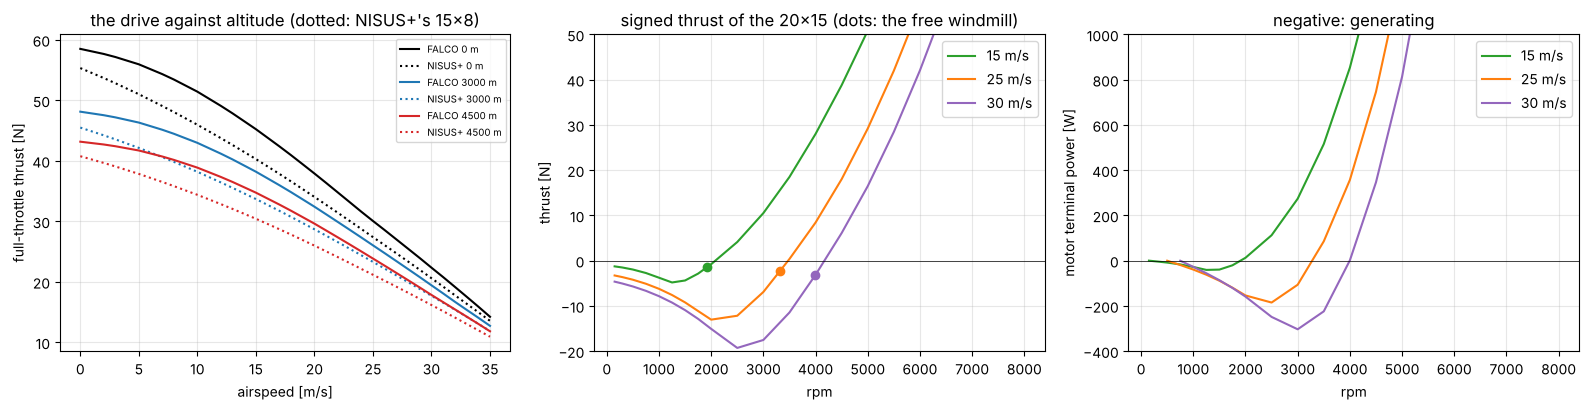

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
DRN = nps.drive()
for h, col in ((0, "k"), (3000, "C0"), (4500, "C3")):
    rho = fs.atmosphere(h)["rho"]
    V = np.linspace(0, 35, 36)
    ax[0].plot(V, [DR.max_thrust(v, rho) for v in V], color=col, label=f"FALCO {h} m")
    ax[0].plot(V, [DRN.max_thrust(v, rho) for v in V], color=col, ls=":", label=f"NISUS+ {h} m")
for V, col in ((15, "C2"), (25, "C1"), (30, "C4")):
    r = DR.rows(V)
    ax[1].plot(r["rpm"], r["thrust"], color=col, label=f"{V} m/s")
    ax[2].plot(r["rpm"], np.where(r["voltage"] > 0, r["voltage"] * r["current"], np.nan), color=col, label=f"{V} m/s")
    fw = DR.freewheel(V)
    ax[1].plot(fw["rpm"], fw["thrust"], "o", color=col)
ax[0].set(xlabel="airspeed [m/s]", ylabel="full-throttle thrust [N]", title="the drive against altitude (dotted: NISUS+'s 15x8)"); ax[0].legend(fontsize=7)
ax[1].axhline(0, color="k", lw=0.5); ax[1].set(xlabel="rpm", ylabel="thrust [N]", title="signed thrust of the 20x15 (dots: the free windmill)", ylim=(-20, 50)); ax[1].legend()
ax[2].axhline(0, color="k", lw=0.5); ax[2].set(xlabel="rpm", ylabel="motor terminal power [W]", title="negative: generating", ylim=(-400, 1000)); ax[2].legend()
for a in ax: a.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(OUT / "plots" / "drive.png", dpi=110); plt.show()

## The Li-ion pack: 8S3P

NISUS+'s cells (Molicel P45B) in series-parallel 8S3P: 28.8 V nominal, 13.5 Ah, the same 388 Wh and the same
264 x 76 x 47 mm box; more resistance (46 mΩ against 28) at less current, the charge window 40 A (3 x 13.5).

,pack,cells,V nom,Ah,Wh nominal,mass [g],Wh/kg,max A (cells),max charge A,R at 25 °C [mΩ],size [mm],"usable Wh at 25 °C, 20 A","sag at 50 A, 25 °C [V]","usable Wh at 5 °C, 20 A","sag at 50 A, 5 °C [V]","usable Wh at -10 °C, 20 A","sag at 50 A, -10 °C [V]"
8s3p-p45b,8S3P Molicel INR21700-P45B,24,28.8,13.5,388.8,1814.4,214.285714,135.0,40.5,46.0,264x76x47,376.530053,2.3,344.015961,4.3,295.809244,7.027171
6s3p-p45b,6S3P Molicel INR21700-P45B,18,21.6,13.5,291.6,1360.8,214.285714,135.0,40.5,36.0,200x76x47,281.398582,1.8,257.645542,3.3,220.995091,5.345378
6s4p-p45b,6S4P Molicel INR21700-P45B,24,21.6,18.0,388.8,1814.4,214.285714,180.0,54.0,28.5,264x76x47,378.614263,1.425,349.968683,2.55,310.646095,4.084034
6s3p-p50b,6S3P Molicel INR21700-P50B,18,21.6,15.0,324.0,1360.8,238.095238,180.0,30.0,36.0,200x76x47,312.665091,1.8,286.272825,3.3,245.550101,5.345378
6s5p-p45b,6S5P Molicel INR21700-P45B,30,21.6,22.5,486.0,2268.0,214.285714,225.0,67.5,24.0,328x76x47,476.241291,1.2,442.11543,2.1,397.563187,3.327227


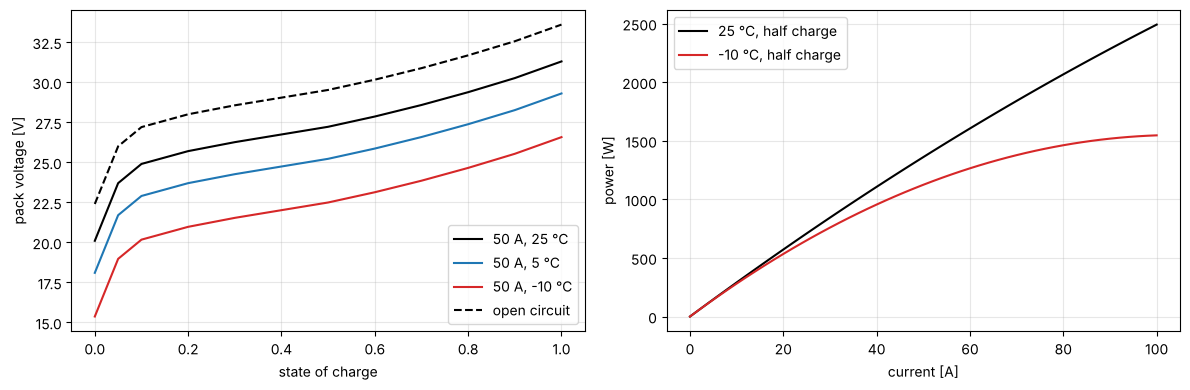

In [13]:
display(save_table(fs.pack_table().round(2), "packs"))
b = fs.pack()
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
soc = np.linspace(0, 1, 101)
for T, col in ((25, "k"), (5, "C0"), (-10, "C3")):
    ax[0].plot(soc, b.terminal_v(50.0, soc, T), color=col, label=f"50 A, {T} °C")
ax[0].plot(soc, b.ocv(soc), "k--", label="open circuit"); ax[0].set(xlabel="state of charge", ylabel="pack voltage [V]"); ax[0].legend(); ax[0].grid(alpha=0.3)
I = np.linspace(0, 100, 51)
for T, col in ((25, "k"), (-10, "C3")):
    ax[1].plot(I, I * b.terminal_v(I, 0.5, T), color=col, label=f"{T} °C, half charge")
ax[1].set(xlabel="current [A]", ylabel="power [W]"); ax[1].legend(); ax[1].grid(alpha=0.3)
fig.tight_layout(); plt.show()

# Part 7 — aerodynamics: the lattice, one fin, crow, the tractor's installation effects

NISUS+'s lattice on FALCO's planform (the same wing and stabiliser; the single fin enters the lateral derivatives at
the plate's own aspect ratio, its side force and its height above the tube) and the longer body in the pod's pitching
term. The **installation effects** of the nose propeller — MERLIN's open-propeller model (`air_propeller` + Boreas'
wake): the wake fraction and the thrust deduction at the flight points — are small for a tractor (the body sits behind
the disc) and enter the airframe's Cd0 at cruise; the slipstream's scrubbing of the fuselage and the wing root is **not**
in the build-up: the CFD rotor-disk case is its check (NOT RUN here).

In [14]:
display(pd.Series({k: v for k, v in A.items() if isinstance(v, float)}, name="lattice").to_frame().round(4))
display(save_table(ff.crow_table(P, a=A).round(4), "crow_increments"))
CIZ = CI[fs.DEFAULT_PACK]
DER = ff.derivatives(P, x_cg_m=CIZ["x_cg_m"], z_cg_m=CIZ["z_cg_m"], a=A, h_m=3000.0)
display(save_table(DER, "derivatives"))
AF = {h: ff.airframe(fs.DEFAULT_PACK, P, h_m=h, a=A) for h in tqdm((0.0, 3000.0, 4500.0), desc="airframes (build-up + installation effects)")}
display(pd.DataFrame({h: {k: v for k, v in vars(a).items() if not isinstance(v, dict)} for h, a in AF.items()}).T)
display(save_table(ff.installation_table(AF[3000.0], DR, P), "installation_effects"))

,lattice
S_ref,0.6000
c_ref,0.2533
AR,9.6000
b,2.4000
x_ref,0.0750
CL0,0.3932
CLa,5.3982
Cm0,0.0165
Cma,-1.1551
Cma_lattice,-1.2080


,dCL,dCm,dCD_profile,k_crow,dCL_max
"flap +0°, aileron +0°",0.0000,0.0000,0.0000,0.0330,0.0000
"flap +15°, aileron +0°",0.2745,0.0262,0.0074,0.0313,0.1046
"flap +30°, aileron +0°",0.4297,0.0411,0.0278,0.0308,0.2092
"flap +30°, aileron -15°",0.1406,0.0632,0.0359,0.0303,0.0631
"flap +45°, aileron -20°",0.1151,0.0726,0.0697,0.0299,0.0841
"flap +55°, aileron -25°",0.0956,0.0801,0.0961,0.0296,0.0354
"flap +60°, aileron -30°",0.0631,0.0840,0.1135,0.0295,-0.0133
"flap +0°, aileron -25°",-0.4121,0.0316,0.0216,0.0356,-0.2435


,value,unit,source,note
derivative,,,,
CL0,0.393212,-,calculated (lattice),lift at α = 0 from the pod axis: wing incidence and camber
CLa,5.398226,1/rad,calculated (lattice),"lift slope, wing + tail"
CLq,3.250925,1/rad,calculated (analytic),2 η CLα_t V_h
CLde,0.354850,1/rad,calculated (lattice),elevator effectiveness τ = 0.55
CLdf,1.094240,1/rad,calculated (lattice),"both flaps, linear (τ = 0.62); K(δ) for large deflections"
Cmdf,0.137369,1/rad,calculated (lattice),"both flaps, about the CG, linear"
CLda_sym,1.152431,1/rad,calculated (lattice),"both ailerons the same way (crow's reflex), linear"
Cmda_sym,-0.053844,1/rad,calculated (lattice),"both ailerons the same way, about the CG"
dCL_crow,0.095639,-,"calculated (lattice, K(δ) assumed)",crow flaps 55° / ailerons -25°


airframes (build-up + installation effects):   0%|          | 0/3 [00:00<?, ?it/s]

,name,mass_kg,wing_area_m2,aspect_ratio,cd0,oswald,cl_max,cd0_buildup,cd0_installation
0.0,Falco-Zero,5.349686,0.6,9.6,0.025646,0.90296,1.17,0.02487,0.000776
3000.0,Falco-Zero,5.349686,0.6,9.6,0.026095,0.90296,1.17,0.025311,0.000784
4500.0,Falco-Zero,5.349686,0.6,9.6,0.026335,0.90296,1.17,0.025546,0.000788


,TAS [m/s],thrust [N],wake fraction w,thrust deduction t,installation drag t·T [N],as ΔCd0,source
"cruise 18 m/s EAS, 3000 m",20.894291,3.956494,0.013351,0.024207,0.095776,0.000804,calculated: air_propeller + boreas.wake on FALCO's pod (the slipstream over the wing root is not in it)
"climb 16 m/s EAS at 6 m/s, 1200 m",16.96207,22.09392,0.014584,0.025416,0.56154,0.005969,calculated: air_propeller + boreas.wake on FALCO's pod (the slipstream over the wing root is not in it)
"dash 30 m/s EAS, 3000 m",34.823818,8.936646,0.012986,0.023385,0.208986,0.000632,calculated: air_propeller + boreas.wake on FALCO's pod (the slipstream over the wing root is not in it)


## Whole-aircraft CFD at altitude (Aeromant / OpenFOAM) — NOT RUN

NISUS+'s cases in the ISA air of 3000 m (the α sweep, crow at V_FE against the clean aircraft) plus the tractor's own:
the 20x15 as a rotor disk **ahead of the nose** at the cruise rpm (the slipstream over the fuselage and the wing root),
and crow with the braked disk. No OpenFOAM in this session: the table lists them.

In [15]:
atm3 = fs.atmosphere(3000.0)
V3 = ff.V_CRUISE_EAS / math.sqrt(atm3["sigma"])
CRUISE_RPM = DR.at(V3, DR.throttle_for_thrust(V3, AF[3000.0].drag(V3, atm3["rho"]), atm3["rho"]), atm3["rho"])["rpm"]
BRAKE_RPM = DR.brake(ff.V_FE_EAS / math.sqrt(atm3["sigma"]), 1.0, atm3["rho"])["rpm"]
if RUN_CFD:
    CFD_CASES = fcfd.plan(ROOT / "cfd", x_cg_m=CIZ["x_cg_m"], z_cg_m=CIZ["z_cg_m"], cruise_rpm=CRUISE_RPM, brake_rpm=BRAKE_RPM, fine=not QUICK)
    names = list(CFD_CASES)
    res = aeromant.run_cases([CFD_CASES[n] for n in names], jobs=1, processors=4, progress=True, cache=True)
    CFD = dict(zip(names, res))
    CFDT = fcfd.table(CFD, P)
else:
    CFD = {n: None for n in fcfd.specs(cruise_rpm=CRUISE_RPM, brake_rpm=BRAKE_RPM, fine=not QUICK)}
    CFDT = fcfd.not_run_table(cruise_rpm=CRUISE_RPM, brake_rpm=BRAKE_RPM)
STATUS["CFD"] = "run" if RUN_CFD and (CFDT["status"] == "solved").any() else "NOT RUN"
display(save_table(CFDT, "cfd_results"))

,status,α [deg],V [m/s EAS],TAS [m/s],altitude [m],ρ [kg/m³],template,quality,crow,propeller rpm
"α -2°, 18 m/s EAS, 3000 m",NOT RUN,-2.0,18.0,20.894291,3000.0,0.90913,rans_ksst_external,screening,,
"α +2°, 18 m/s EAS, 3000 m",NOT RUN,2.0,18.0,20.894291,3000.0,0.90913,rans_ksst_external,screening,,
"α +6°, 18 m/s EAS, 3000 m",NOT RUN,6.0,18.0,20.894291,3000.0,0.90913,rans_ksst_external,screening,,
"α +10°, 18 m/s EAS, 3000 m",NOT RUN,10.0,18.0,20.894291,3000.0,0.90913,rans_ksst_external,screening,,
"crow 55/-25, α +0°, 22 m/s EAS",NOT RUN,0.0,22.0,25.537467,3000.0,0.90913,rans_ksst_external,screening,"(55.0, -25.0)",
"crow 55/-25, α +4°, 22 m/s EAS",NOT RUN,4.0,22.0,25.537467,3000.0,0.90913,rans_ksst_external,screening,"(55.0, -25.0)",
"clean, α +0°, 22 m/s EAS (crow's reference)",NOT RUN,0.0,22.0,25.537467,3000.0,0.90913,rans_ksst_external,screening,,
"α +2°, cruise, nose propeller 3296 rpm (the slipstream over the body)",NOT RUN,2.0,18.0,20.894291,3000.0,0.90913,hull_rotor_disk,screening,,3295.837983
"crow at V_FE, propeller braked 1998 rpm",NOT RUN,0.0,22.0,25.537467,3000.0,0.90913,hull_rotor_disk,screening,"(55.0, -25.0)",1997.969067
"α +2°, cruise, fine mesh",NOT RUN,2.0,18.0,20.894291,3000.0,0.90913,rans_ksst_external,fine,,


# Part 8 — structure

NISUS+'s load cases on FALCO's mass, drive and tail areas, plus the tractor's: the propeller's gyroscopic moment on the
firewall at the pull-out's pitch rate, the single tube's torsion from the one fin, and the **blade strike** — what the
meadow does to a 20-inch blade straight down at the touchdown speed: not a design case, the number that says why the
parking must work. The joints by hand: the keel socket's bearing and epoxy, the tube at its exit under the tail's lift
and the fin's side load together (bending + torsion with the roll-wrapped tube's G: the frame study's sizing term),
the stabiliser's 12/10 spar and the fin's rod on the end fitting (the first 8/6 rod came out at margin −0.03 under the
fin's ultimate side load: now 10/8), the firewall's screws, the straps, the flap horn. Talos: the spar and the joiner
(NISUS+'s cases), the **tail tube** A (symmetric pull-out) and B (the asymmetric gust) with the modal model on the frame
study's machinery (the saddle blocks, the sound-mesh retry), the **keel socket** (PETG) under the tube's bearing couple,
the **firewall** in flight, braking and landing, the battery tray.

In [16]:
LC = fst.load_cases(P, dr=DR, a=A)
display(save_table(LC, "load_cases"))
display(save_table(fst.wing_hand(P, LC), "wing_hand"))
display(save_table(fst.joints_hand(P, LC), "joints_hand"))

,value,basis
design mass [kg],5.77766,6S4P + 8 % (MTOM)
manoeuvre limit n,4.4,nisus_plus_flight.N_STRUCTURAL: the pull-out after a fast descent
"gust n at V_C = 22 m/s EAS, U = 10 m/s",6.179553,"Pratt in EAS, μ at sea level and at 4000 m: the larger"
"gust n at V_NE = 35 m/s EAS, U = 5 m/s",5.120099,Pratt in EAS
lift-limited n at V_NE,9.29305,CL_max at V_NE: the gust cannot exceed it
design limit n (wing),6.179553,max of manoeuvre and gusts
ultimate n (wing),9.269329,x 1.5
"tail load at V_NE, limit [N]",63.8666,"q S_h cl_max_t (0.8), both booms"
"fin side load at V_NE, limit [N]",58.3443,"q S_v1 cl_max_t, per fin"
"tail load to trim crow at V_FE, limit [N]",4.613584,ΔCm_crow +0.080 x q S c / l_t


,value
"root bending moment, ultimate [N m]",122.714356
"spar stress, ultimate [MPa]",326.87618
spar margin (500 MPa x 0.8 knock-down),0.223705
"spar tip deflection at y = 1000 mm, ultimate [mm]",63.012653
"joint: shear / moment at the panel joint, ultimate [N / N m]",121.9 / 35.52
"joiner stress at the joint, ultimate [MPa]",130.872462
joiner margin (500 MPa x 0.8),2.056411
joiner bearing on the panel's spar [MPa],1.065184
joiner bearing margin (tube crushing 60 MPa assumed x 0.8),44.062636
"torque per wing at V_NE, ultimate [N m]",11.119631


,value
keel socket: length [mm],200.000000
"keel socket: bearing reaction at the exit, ultimate [N]",267.042221
keel socket: bearing on the PETG bore [MPa],0.133521
keel socket: bearing margin (PETG 45 MPa x 0.7 x 0.5 for the layers),116.958875
keel socket: epoxy shear [MPa],0.028334
keel socket: margin (epoxy on PETG 5 MPa x 0.5),87.233032
"tail tube: bending at the socket exit, tail + fin ultimate [MPa]",67.298518
"tail tube: torsion shear from the fin, ultimate [MPa]",12.115860
tail tube: von Mises at the exit [MPa],70.494487
tail tube: margin (500 MPa x 0.8),4.674203


In [17]:
FEA_CASES = fst.models(ROOT / "fea", P, LC)
FEA = {}
if RUN_FEA:
    bar = tqdm(total=len(FEA_CASES), desc="FEA (spar, joiner, socket, firewall x3, tray)", bar_format="{desc}: {n_fmt}/{total_fmt} |{bar}| {elapsed} {postfix}")
for c in FEA_CASES:
    if RUN_FEA:
        bar.set_postfix_str(c.name)
    FEA[c.name] = c.model.ensure(ROOT / "fea" / c.name, run=RUN_FEA, threads=4)
    if RUN_FEA:
        bar.update(1)
if RUN_FEA:
    bar.close()
TT_CASES, TT = fst.solve_tail_tube(ROOT / "fea_tail", P, LC, run=RUN_FEA, threads=4, progress=RUN_FEA)
FEAT = pd.DataFrame([fst.summary_row(c, FEA[c.name]) for c in FEA_CASES] + [fst.summary_row(c, TT[c.name]) for c in TT_CASES if c.kind == "static"]).set_index("case")
STATUS["FEA"] = "run" if (FEAT["status"] == "solved").any() else "NOT RUN"
display(save_table(FEAT.T, "fea_results"))
display(save_table(fst.tail_tube_table(TT_CASES, TT, P), "tail_tube_fea"))
display(save_table(fst.tail_tube_modes(TT_CASES, TT), "tail_tube_modes"))
display(pd.DataFrame(fst.NOT_ESTABLISHED, columns=["not established", "why"]).set_index("not established"))

FEA (spar, joiner, socket, firewall x3, tray): 0/7 |          | 00:00 

tail tube FEA: 0/3 |          | 00:00 

tail tube: unsound mesh — tail_tube_A: reaction 137.7 N against 129.8 N applied


tail tube FEA (retry 1): 0/3 |          | 00:00 

case,spar_pullup,spar_joiner,tail_socket,motor_mount_flight,motor_mount_brake,motor_mount_landing,battery_tray,tail_tube_A,tail_tube_B
status,solved,solved,solved,solved,solved,solved,solved,solved,solved
description,"spar tube (right half), ultimate n = 9.27, Schrenk lift on 7 segments","spar joiner: joint shear 122 N, moment 35.5 N m (ultimate) as bearing 427 N / -305 N","keel socket (PETG): the tube's bearing 267 N down at the exit, 171 N up at the front, the fin's 218 N side...","firewall, flight: thrust 87.8 N, torque 8.20 N m, inertia 54.3 N (ultimate); skirt bonded in the cowl","firewall, brake: thrust -39.6 N, torque -1.67 N m, inertia 54.3 N (ultimate); skirt bonded in the cowl","firewall, landing: thrust 0.0 N, torque 0.00 N m, inertia 148.7 N (ultimate); skirt bonded in the cowl","battery tray: 452 N down on the floor, 267 N on a lip (ultimate)","FALCO tail tube 30/28 roll-wrapped: symmetric pull-out: stabiliser 96 N up, fin 88 N side (ultimate)","FALCO tail tube 30/28 roll-wrapped: asymmetric: the left half's 48 N only, fin 88 N side (ultimate)"
peak von Mises [MPa],335.510195,163.702081,0.761832,5.744154,2.194621,1.376819,12.889295,90.664377,124.090787
nominal von Mises [MPa],295.52922,132.844918,NaN,NaN,NaN,NaN,NaN,71.286005,60.59408
99.5th percentile von Mises [MPa],271.195864,135.112781,0.4968,2.846396,1.075542,0.751947,3.876661,69.1642,59.379938
max displacement [mm],58.010555,0.774844,0.007017,0.101127,0.043261,0.011621,0.216222,5.486762,5.670778
allowable [MPa],400.0,400.0,31.5,31.5,31.5,31.5,31.5,400.0,400.0
margin (governing),0.353504,2.01103,40.347673,4.483837,13.353276,21.878831,1.443888,4.6112,5.601305
governing stress,nominal (≥ 1 diameter from the support),nominal (≥ 1 diameter from the support),peak,peak,peak,peak,peak,nominal (≥ 1 diameter from the support),nominal (≥ 1 diameter from the support)
reaction [N],233.5569,121.8747,129.756502,104.786236,66.064123,148.706688,523.735565,129.756502,99.767401


,status,description,peak von Mises [MPa],nominal von Mises [MPa],99.5th percentile von Mises [MPa],max displacement [mm],allowable [MPa],margin (governing),governing stress,reaction [N],applied [N],tail heave at the tube(s) [mm],tail roll [deg],fin yaw twist at its AC [deg] (isotropic G)
case,,,,,,,,,,,,,,
tail_tube_A,solved,"FALCO tail tube 30/28 roll-wrapped: symmetric pull-out: stabiliser 96 N up, fin 88 N side (ultimate)",90.664377,71.286005,69.164200,5.486762,400.0,4.611200,nominal (≥ 1 diameter from the support),129.756502,129.756502,1.415744,-0.383662,0.458795
tail_tube_B,solved,"FALCO tail tube 30/28 roll-wrapped: asymmetric: the left half's 48 N only, fin 88 N side (ultimate)",124.090787,60.594080,59.379938,5.670778,400.0,5.601305,nominal (≥ 1 diameter from the support),99.767401,99.767401,0.708159,-0.581348,0.629345


,status,mode 1 [Hz],mode 2 [Hz],mode 3 [Hz],mode 4 [Hz],mode 5 [Hz],torsion note
falco,solved,57.97337,61.00832,82.70838,117.1508,121.4709,isotropic G 46 GPa: a torsional mode is optimistic x 1.5


,why
not established,
buckling,"local buckling of the 10/8 mm tubes (D/t = 10: a thick tube, the material fails first by hand); the foam c..."
adhesive failure,"the epoxy bonds (spar–foam, boom socket, fitting–wing) are tied contacts in the FEA or hand checks with an..."
nonlinear effects,"large deflection of the wing (geometric nonlinearity) at the ultimate load, PETG's yielding and creep unde..."
anisotropy,the carbon tube is modelled with its axial modulus only; the printed parts are isotropic with a separate c...
dynamics,"the loads are quasi-static: the landing impact's dynamic overshoot, flutter of the ailerons and the tail o..."
the crow flaps' separated loads,the 55° flap's normal force and hinge moment are coefficients assumed for a separated plain flap; buffet o...
cold,"the printed PETG and the epoxy at −10 °C (stiffer, more brittle), the foam's contraction against the carbo..."
flutter at TAS,"the never-exceed speed is an EAS; flutter depends on the TAS, 25 % higher at 4000 m: the wing's torsion an..."
the parked propeller,the ESC's brake stops the blades where they are; the parking nudge and the Hall sensor are a bench item: u...


# Part 9 — flight against altitude, and NISUS+ against FALCO

Trim (with crow), the CG range (one fin, the long nose), the envelope at 0-6000 m, the ceiling, the climb strategy,
the descent in four configurations (the braked 20x15 is a bigger airbrake than the 15x8), the regeneration, the
downdraft escape, the launch, the limits — and the **side-by-side table**: static thrust, top speed, the acceleration
at the launch and at cruise, 15 → 25 m/s, the best climb, L/D, the cruise power at 1200 / 3000 / 4500 m, the
mission's energy and survey time, each aircraft at its design mass on its own drive map.

In [18]:
AFW = AF[3000.0]
display(pd.DataFrame([ff.trim(DER, AFW.mass_kg, v / math.sqrt(fs.atmosphere(h)["sigma"]), fs.atmosphere(h)["rho"]) | {"h": h} for h in (0, 3000, 4500) for v in (16, 18, 22)]).round(2))
display(pd.DataFrame([ff.trim_crow(DER, AFW.mass_kg, 22.0, RHO0, 1.0, g) | {"γ": g} for g in (0, 15, 30)]).round(2))
CGR = ff.cg_range(P, AFW.mass_kg, a=A)
display(pd.Series(CGR).to_frame("CG range"))
EL = fs.phase_power()["electronics battery-side [W]"]
with tqdm(total=1, desc="envelope against altitude (0-6000 m)") as bar_env:
    ENV = ff.envelope_vs_altitude(AFW, DR, electronics_w=EL["survey"], battery_wh=fs.pack().energy_wh); bar_env.update(1)
display(save_table(ENV.round(2), "envelope_vs_altitude"))
display(pd.Series(ff.ceiling(AFW, DR)).to_frame("ceiling"))
display(pd.Series(ff.ceiling(AFW, DR, dT=20.0)).to_frame("ceiling, ISA +20"))

,V,CL,alpha_deg,elevator_deg,stalled,h
0,16.00,0.56,1.76,-0.12,False,0
1,18.00,0.44,0.42,1.22,False,0
2,22.00,0.30,-1.23,2.90,False,0
3,18.57,0.56,1.76,-0.12,False,3000
4,20.89,0.44,0.42,1.22,False,3000
5,25.54,0.30,-1.23,2.90,False,3000
6,20.09,0.56,1.76,-0.12,False,4500
7,22.60,0.44,0.42,1.22,False,4500
8,27.63,0.30,-1.23,2.90,False,4500


,V,CL,alpha_deg,elevator_deg,stalled,γ
0,22.0,0.30,-2.66,9.18,False,0
1,22.0,0.28,-2.77,9.30,False,15
2,22.0,0.26,-3.11,9.64,False,30


,CG range
x_fwd_m,-0.000312
x_aft_m,0.116543
fwd_frac_mac,-0.047284
aft_frac_mac,0.413984
x_np_frac_mac,0.463984
sm_min,0.050000
de_max_deg,20.000000


envelope against altitude (0-6000 m):   0%|          | 0/1 [00:00<?, ?it/s]

,σ,stall TAS [m/s],best-climb TAS [m/s],climb max [m/s],min power [W],at TAS [m/s],endurance [min],top speed TAS [m/s],L/D max,min sink [m/s],V_NE TAS [m/s]
0 m,1.00,11.05,19.16,12.75,109.26,11.60,163.34,35.00,16.15,0.74,35.00
1500 m,0.86,11.89,19.60,11.83,114.03,12.48,156.51,36.39,16.15,0.79,37.66
3000 m,0.74,12.82,20.05,10.92,119.23,13.47,149.67,36.79,16.15,0.86,40.63
4500 m,0.63,13.87,20.21,9.95,127.54,14.57,139.92,37.13,16.15,0.93,43.95
6000 m,0.54,15.05,20.64,8.93,133.72,15.81,133.46,37.71,16.15,1.00,47.69


,ceiling
service_ceiling_m,9000.0
absolute_ceiling_m,9000.0
service_roc,0.5
dT,0.0
note,"the drive scales with the density only (no Reynolds or Mach effect on the blades), the pack at its nominal..."


,"ceiling, ISA +20"
service_ceiling_m,9000.0
absolute_ceiling_m,9000.0
service_roc,0.5
dT,20.0
note,"the drive scales with the density only (no Reynolds or Mach effect on the blades), the pack at its nominal..."


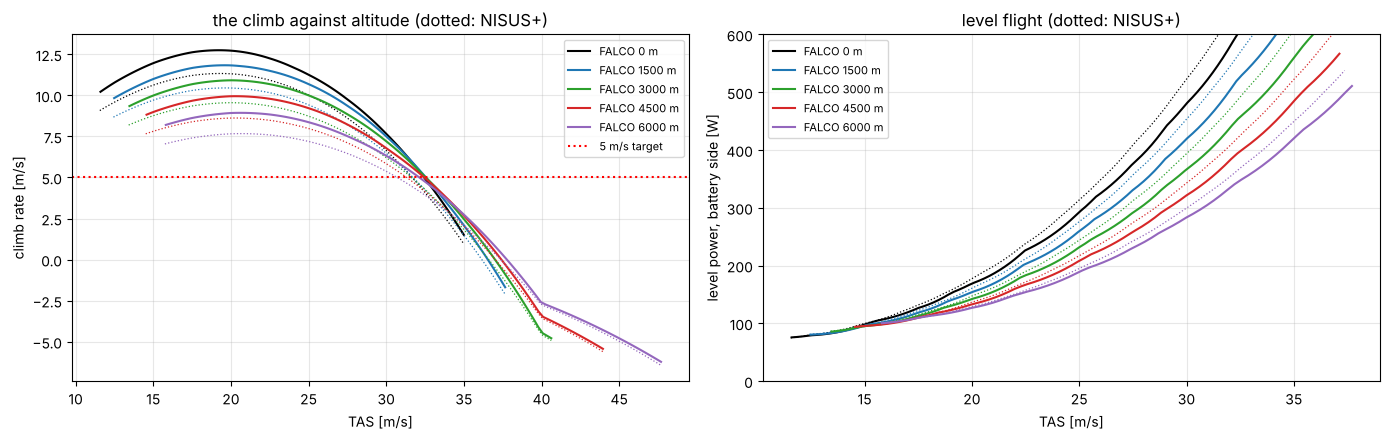

,climb rate held (mean) [m/s],capped by the drive,time [min],propulsion [Wh],electronics [Wh],total [Wh],per 100 m [Wh],potential energy share,horizontal [km]
2 m/s,2.0,False,23.333333,114.104547,13.066667,127.171214,4.541829,0.32097,25.351676
3 m/s,3.0,False,15.555556,101.012371,8.711111,109.723482,3.918696,0.372009,16.771539
4 m/s,4.0,False,11.666667,95.666081,6.533333,102.199414,3.649979,0.399397,12.441312
5 m/s,5.0,False,9.333333,93.429956,5.226667,98.656622,3.523451,0.413739,9.809962
6 m/s,6.0,False,7.777778,92.605793,4.355556,96.961349,3.462905,0.420973,8.026806
7 m/s,7.0,False,6.666667,92.666273,3.733333,96.399606,3.442843,0.423426,6.726915
8 m/s,8.0,False,5.833333,93.227827,3.266667,96.494494,3.446232,0.42301,5.727438
10 m/s,9.999245,True,4.667019,95.19172,2.613531,97.805251,3.493045,0.417341,4.262327


In [19]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
AFN = npf.airframe(nps.DEFAULT_PACK, h_m=3000.0)
for h, col in ((0, "k"), (1500, "C0"), (3000, "C2"), (4500, "C3"), (6000, "C4")):
    e = ff.envelope(AFW, DR, h)
    en = npf.envelope(AFN, DRN, h)
    ax[0].plot(e["V"], e["roc"], color=col, label=f"FALCO {h} m"); ax[0].plot(en["V"], en["roc"], color=col, ls=":", lw=0.9)
    ax[1].plot(e["V"], e["P_level"], color=col, label=f"FALCO {h} m"); ax[1].plot(en["V"], en["P_level"], color=col, ls=":", lw=0.9)
ax[0].axhline(5.0, color="r", ls=":", label="5 m/s target"); ax[0].set(xlabel="TAS [m/s]", ylabel="climb rate [m/s]", title="the climb against altitude (dotted: NISUS+)")
ax[1].set(xlabel="TAS [m/s]", ylabel="level power, battery side [W]", ylim=(0, 600), title="level flight (dotted: NISUS+)")
for a in ax: a.grid(alpha=0.3); a.legend(fontsize=8)
fig.tight_layout(); fig.savefig(OUT / "plots" / "envelope.png", dpi=110); plt.show()
CS = ff.climb_strategy(DR, AFW)
display(save_table(CS.round(2), "climb_strategy"))

,EAS [m/s],TAS [m/s],configuration,sink [m/s],path angle [deg],propeller thrust [N],battery side [W],rpm,mode,CL,stalls
0,14.0,16.25,"clean, motor freewheeling",1.42,5.03,-1.33,0.00,2073.35,freewheel,0.73,False
1,14.0,16.25,crow,3.51,12.49,-1.33,0.00,2073.35,freewheel,0.71,False
2,14.0,16.25,propeller brake,2.27,8.03,-4.08,-38.39,1486.57,regen,0.72,False
3,14.0,16.25,crow + propeller brake,4.36,15.54,-4.08,-38.39,1486.57,regen,0.70,False
4,16.0,18.57,"clean, motor freewheeling",1.76,5.45,-1.46,0.00,2400.71,freewheel,0.56,False
5,16.0,18.57,crow,4.91,15.32,-1.46,0.00,2400.71,freewheel,0.54,False
6,16.0,18.57,propeller brake,3.11,9.65,-5.30,-58.78,1722.23,regen,0.55,False
7,16.0,18.57,crow + propeller brake,6.25,19.66,-5.30,-58.78,1722.23,regen,0.53,False
8,18.0,20.89,"clean, motor freewheeling",2.20,6.05,-1.59,0.00,2730.69,freewheel,0.44,False
9,18.0,20.89,crow,6.70,18.71,-1.59,0.00,2730.69,freewheel,0.42,False


,EAS [m/s],TAS [m/s],sink [m/s],path angle [deg],battery side [W]
configuration,,,,,
"clean, motor freewheeling",35.0,40.63,12.22,17.50,0.00
crow,22.0,25.54,11.78,27.46,0.00
crow + propeller brake,22.0,25.54,15.53,37.45,-129.65
propeller brake,35.0,40.63,29.12,45.79,-464.04


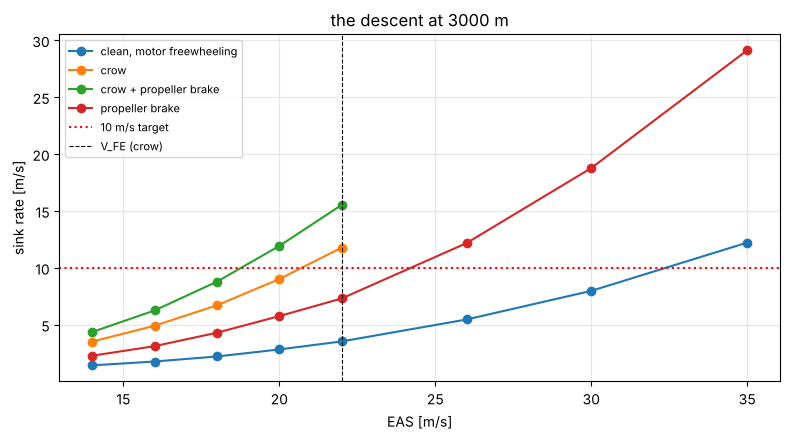

descent time [s]  mean sink [m/s]  recovered [Wh]  recovered per 1000 m [Wh]  share of the pack [%]  share of the potential energy [%]
warm pack                       brake 0.00           242.888           11.528           0.000                      0.000                  0.000                              0.000
                                brake 0.25           215.915           12.968           4.420                      1.579                  1.137                             10.829
                                brake 0.50           197.509           14.177           6.722                      2.401                  1.729                             16.469
                                brake 0.75           188.031           14.891           7.371                      2.632                  1.896                             18.058
                                brake 1.00           182.753           15.321           7.061                      2.522                  1.816                             17.298
cold pack (< 5 °C: no charging) brake 0.00           242.888           11.528           0.000                      0.000                  0.000                              0.000
                                brake 0.25           233.829           11.975           0.000                      0.000                  0.000                              0.000
                                brake 0.50           233.829           11.975           0.000                      0.000                  0.000                              0.000
                                brake 0.75           233.829           11.975           0.000                      0.000                  0.000                              0.000
                                brake 1.00           233.829           11.975           0.000                      0.000                  0.000                              0.000

,climb max [m/s],net in a 2 m/s downdraft [m/s],net in a 4 m/s downdraft [m/s],net in a 6 m/s downdraft [m/s]
1500 m,11.83,9.83,7.83,5.83
3000 m,10.92,8.92,6.92,4.92
4000 m,10.28,8.28,6.28,4.28
4500 m,9.95,7.95,5.95,3.95


V_stall_flaps static_T_over_W height_lost_m time_to_1.2Vs_s height_after_s    ok
1200 m 9 m/s      11.221345        1.034098          -0.0            0.58       5.925836  True
       11 m/s     11.221345        1.034098          -0.0            0.35      10.862919  True
       18 m/s     11.221345        1.034098          -0.0            0.01      11.560085  True
2000 m 9 m/s      11.677433        0.980923          -0.0            0.67       3.961159  True
       11 m/s     11.677433        0.980923          -0.0            0.46      10.187424  True
       18 m/s     11.677433        0.980923          -0.0            0.01      11.500334  True
3000 m 9 m/s      12.286868         0.91692      0.386261             0.8       1.008866  True
       11 m/s     12.286868         0.91692          -0.0             0.6       8.794014  True
       18 m/s     12.286868         0.91692          -0.0            0.01      11.411848  True

,value,basis
"stall speed, level [m/s EAS]",11.047831,"CL_max 1.17 (clean, assumed); TAS at 4000 m: 13.5"
minimum speed in flight [m/s EAS],13.809789,1.25 Vs (the mountain air's gusts)
approach speed [m/s EAS],14.362181,"1.3 Vs, crow set"
cruise speed [m/s EAS],18.0,TAS at 4000 m: 22.0
never-exceed speed [m/s EAS],35.0,TAS at 4000 m: 42.8; flutter is a TAS problem: not computed (todo)
maximum flap-extended (crow) speed V_FE [m/s EAS],22.0,the flaps' hinge loads and servo (nisus_plus_systems.servo_check)
manoeuvring speed V_A [m/s EAS],23.174126,n = 4.4 at CL_max
limit load factor,4.4,the pull-out after a fast descent; the mountain gusts (nisus_plus_structure)
"maximum bank, survey turns [deg]",45.0,n = 1.41
best climb at 4000 m [m/s],10.276752,"at 20.3 m/s TAS, full throttle"


In [20]:
DT = ff.descent_table(AFW, DR, DER, 3000.0)
display(save_table(DT.round(2), "descent_3000m"))
best = ff.best_descent(DT)
display(save_table(best[["EAS [m/s]", "TAS [m/s]", "sink [m/s]", "path angle [deg]", "battery side [W]"]].round(2), "best_descent"))
fig, ax = plt.subplots(figsize=(8, 4.5))
for name, g in DT.groupby("configuration"):
    ax.plot(g["EAS [m/s]"], g["sink [m/s]"], "o-", label=name)
ax.axhline(10, color="r", ls=":", label="10 m/s target"); ax.axvline(ff.V_FE_EAS, color="k", ls="--", lw=0.8, label="V_FE (crow)")
ax.set(xlabel="EAS [m/s]", ylabel="sink rate [m/s]", title="the descent at 3000 m"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(OUT / "plots" / "descent.png", dpi=110); plt.show()
REGEN = ff.regen_table(AFW, DR, DER, pk=fs.pack())
display(save_table(REGEN.round(3), "regeneration"))
display(save_table(ff.downdraft_escape(AFW, DR).round(2), "downdraft_escape"))
display(save_table(ff.launch_table(AFW, DR, a=A, p=P).round(2), "launch"))
display(save_table(ff.operating_limits(AFW, DR, DER, CGR), "operating_limits"))

## NISUS+ vs FALCO

,Nisus+ Zero,Falco-Zero,FALCO vs NISUS+ [%]
mass [kg],5.309971,5.349686,0.747930
wing area [m²],0.6,0.6,0.000000
Cd0 (build-up + installation),0.026182,0.025821,-1.378780
drag area Cd0·S [m²],0.015709,0.015493,-1.378780
Oswald e,0.900128,0.90296,0.314595
propeller,T-Motor AT4125 KV540 (fitted),T-Motor AT5220-A KV220 (fitted),NaN
pack,6S4P Molicel INR21700-P45B,8S3P Molicel INR21700-P45B,NaN
pack energy [Wh],388.8,388.8,0.000000
"static thrust, sea level [N]",55.329232,58.502134,5.734586
static T/W,1.062169,1.114742,4.949636


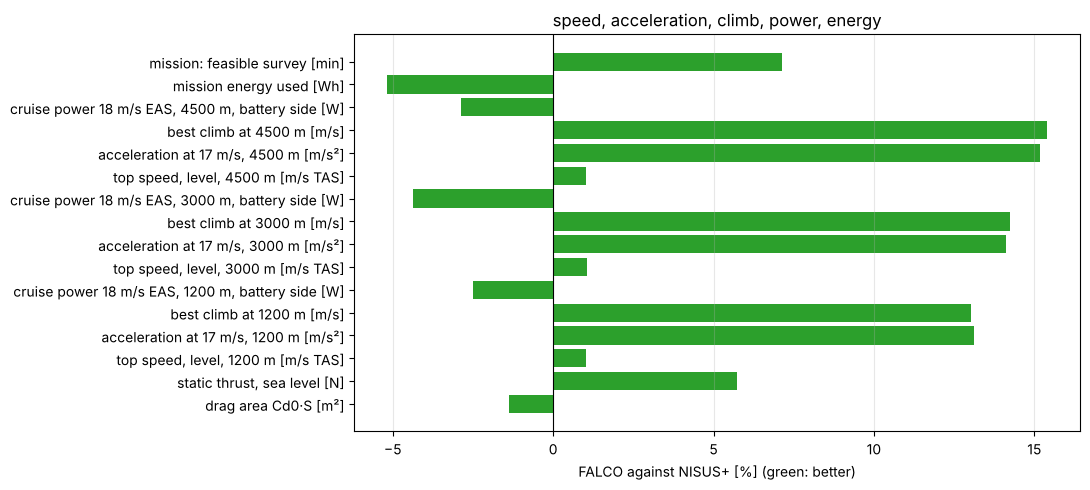

In [21]:
CMPX = ff.compare_with_nisus_plus(af_f=ff.airframe(fs.DEFAULT_PACK, P, h_m=1200.0, a=A), dr_f=DR, dr_n=DRN)
display(save_table(CMPX, "nisus_plus_vs_falco"))
num = CMPX.apply(pd.to_numeric, errors="coerce").dropna()
rows = [r for r in num.index if any(k in r for k in ("static thrust", "top speed", "acceleration at 17", "best climb", "cruise power", "mission energy used", "feasible survey", "drag area"))]
fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(rows, num.loc[rows, "FALCO vs NISUS+ [%]"], color=["#2ca02c" if (v > 0) == ("power" not in r and "energy" not in r and "drag" not in r) else "#d62728" for r, v in zip(rows, num.loc[rows, "FALCO vs NISUS+ [%]"])])
ax.axvline(0, color="k", lw=0.8); ax.set(xlabel="FALCO against NISUS+ [%] (green: better)", title="speed, acceleration, climb, power, energy"); ax.grid(alpha=0.3, axis="x")
fig.tight_layout(); fig.savefig(OUT / "plots" / "nisus_plus_vs_falco.png", dpi=110); plt.show()

# Part 10 — mission energy over the mountains

NISUS+'s sizing mission (300 s on the meadow at 1200 m, the climb to 4000 m at 6 m/s, 3 km out, 20 min of survey,
back, the crow + brake descent at 10 m/s with its regeneration, the approach; 20 % reserve) on FALCO's drive and
airframe; the battery iteration shows the 8S3P against the 6S4P on the same aircraft (the same energy; the 6S4P would
need the KV380 at the ESC's limit — Part 6).

In [22]:
REGEN_W = -float(DT[(DT["configuration"] == "crow + propeller brake") & (DT["EAS [m/s]"] == 20.0)]["battery side [W]"].iloc[0])
PLAN = fs.MissionPlan(work_alt_m=4000.0, descent_regen_w=REGEN_W)
afd = ff.airframe_dict(AFW)
ME = fs.mission_energy(fs.pack(), DR, afd, PLAN)
display(save_table(ME["phases"].round(2), "mission_energy"))
display(pd.Series({k: ME[k] for k in ("E_nominal_wh", "E_available_wh", "E_used_wh", "E_left_pct_available", "E_reserve_wh", "reserve_kept", "trigger_wh",
                                      "t_climb_s", "E_climb_wh", "potential_energy_wh", "climb_efficiency", "t_survey_feasible_s")}).to_frame("mission"))
MTAB = fs.mission_table(DR, lambda k: ff.airframe_dict(ff.airframe(k, P, h_m=3000.0, a=A)), PLAN)
display(save_table(MTAB, "battery_iteration"))
MEN = nps.mission_energy(nps.pack(), DRN, npf.airframe_dict(AFN), PLAN)
print(f"NISUS+ on the same plan: {MEN['E_used_wh']:.0f} Wh used, survey up to {MEN['t_survey_feasible_s'] / 60:.0f} min; FALCO: {ME['E_used_wh']:.0f} Wh, {ME['t_survey_feasible_s'] / 60:.0f} min")
COLD = fs.mission_energy(fs.pack(), DR, afd, replace(PLAN, pack_T_C=-5.0, dT=-10.0, descent_regen_w=0.0))
print(f"a cold morning (pack −5 °C, ISA −10): available {COLD['E_available_wh']:.0f} Wh, used {COLD['E_used_wh']:.0f} Wh, left {COLD['E_left_pct_available']:.0f} %, "
      f"reserve kept: {COLD['reserve_kept']}")

,time [s],propulsion [W],electronics [W],propulsion [Wh],electronics [Wh],energy [Wh],energy [kWh],% of nominal
phase,,,,,,,,
ground operation (prelaunch),300.00,0.00,26.91,0.00,2.24,2.24,0.00,0.58
launch + climb 1200 → 4000 m,466.67,714.39,33.57,92.61,4.35,96.96,0.10,24.94
transit,136.29,164.18,31.88,6.22,1.21,7.42,0.01,1.91
survey (terrain following),1200.00,165.88,33.57,55.29,11.19,66.48,0.07,17.10
return transit,136.29,164.18,31.88,6.22,1.21,7.42,0.01,1.91
descent 10 m/s (crow + brake),280.00,0.00,34.70,0.00,2.70,2.70,0.00,0.69
descent: regeneration,280.00,-111.38,0.00,-8.66,0.00,-8.66,-0.01,-2.23
approach + landing,90.00,42.41,35.26,1.06,0.88,1.94,0.00,0.50


,mission
E_nominal_wh,388.8
E_available_wh,331.843048
E_used_wh,176.505992
E_left_pct_available,46.810399
E_reserve_wh,66.36861
reserve_kept,True
trigger_wh,74.674492
t_climb_s,466.666667
E_climb_wh,96.957536
potential_energy_wh,40.818101


,pack mass [g],aircraft mass [kg],nominal [Wh],available [Wh],climb [Wh],climb time [s],survey power [W],used [Wh],left [% avail.],reserve kept,feasible survey [min],20-min survey ok,fits the bay
8S3P Molicel INR21700-P45B,1814.4,5.349686,388.8,331.843048,96.957536,466.666667,165.880429,176.505992,46.810399,True,45.288115,True,True
6S4P Molicel INR21700-P45B,1814.4,5.349686,388.8,335.390894,96.957536,466.666667,165.880429,176.505992,47.373052,True,46.141942,True,True


NISUS+ on the same plan: 187 Wh used, survey up to 42 min; FALCO: 177 Wh, 45 min
a cold morning (pack −5 °C, ISA −10): available 288 Wh, used 184 Wh, left 36 %, reserve kept: True


# Part 11 — the missions in MuJoCo over the mountains (Chiron), the propeller parked for the landing

NISUS+'s simulation (one rigid body with the mass table's rows, `FalcoAero` — NISUS+'s hook — with the density from the
ISA at the aircraft's altitude, the drive at the pack's loaded voltage, the brake that regenerates; the `Massif` and the
`MountainWind`; the TECS-style controller) with FALCO's robot, drive and derivatives. New: the **park** command. On the
9° crow final below 20 m the `FalcoController` sets the throttle to idle and the brake on and commands the park: the
ESC's active brake stops the blades and the parking routine (the Hall sensor, the nudge: 1 s assumed, no rotor inertia
in the model) marks them horizontal — `parked` in the log; the flare is flown on the pitch alone; a go-around clears
the park and the motor spins up. The judge counts a touchdown with the blades not parked as a **blade strike**.

In [23]:
lab = fsc.make_lab(fsc.scenario("calm"), log_geoms=False)
display(pd.Series(fr.inertia_check(lab, lab.aero.robot.mass_table)).to_frame("MuJoCo vs the mass table"))
print("the hook's density at 3000 m:", lab.aero.air(3000.0)[0], "(ISA:", fs.atmosphere(3000.0)["rho"], ")")
M = fr.Massif()
X, Y = np.meshgrid(np.linspace(-3000, 7000, 300), np.linspace(-4000, 5500, 300))

,MuJoCo vs the mass table
mujoco_mass_kg,5.349686e+00
table_mass_kg,5.349686e+00
mass_error,3.626877e-12
mujoco_cg_x_mm,8.441123e+01
table_cg_x_mm,8.260000e+01
mujoco_cg_z_mm,-5.780371e+01
table_cg_z_mm,-5.909549e+01
Ixx_ratio,9.883643e-01
Iyy_ratio,1.040488e+00
Izz_ratio,1.003606e+00


the hook's density at 3000 m: 0.9091296648333497 (ISA: 0.9091296648333497 )


In [24]:
SCNS = [fsc.scenario("calm")] if QUICK else fsc.standard_scenarios()
EPS = []
for scn in tqdm(SCNS, desc="mountain missions (MuJoCo)"):            # one bar over the scenarios; one per mission over its simulated time
    t0 = time.time()
    labs = fsc.make_lab(scn, log_geoms=True)
    ep = fsc.run(labs, scn, progress=True)
    EPS.append((scn, ep))
    fsc.timeseries(ep).to_csv(OUT / "telemetry" / f"{scn.slug}.csv", index=False)
    print(f"{scn.label:48s} {ep.outcome['reason']:20s} {ep.outcome['detail']}  ({time.time() - t0:.0f} s)")
    for e in ep.log["events"]:
        if e[1] in ("weather", "jetson", "energy", "companion lost", "landing", "descent", "propeller") and "charged" not in e[2]:
            print(f"     {e[0]:7.1f} s  {e[1]}: {e[2]}")
CMP = fsc.compare([e for _, e in EPS])
display(save_table(CMP, "missions"))
display(save_table(fsc.park_table([e for _, e in EPS]), "parking"))

mountain missions (MuJoCo):   0%|          | 0/6 [00:00<?, ?it/s]

Falco-Zero — calm: 0/2400 s |          | 00:00 

Falco-Zero — calm                                landed               touchdown 4 m from home, sink 1.3 m/s, 216 Wh left of 325, regenerated 3.5 Wh; propeller parked 1.0 s after the command, 8.4 s before touchdown  (105 s)
       936.6 s  descent: over the meadow at 2657 m (1449 m above it): crow + brake spiral
      1093.9 s  landing: final: 9° crow approach
      1138.5 s  landing: 20 m: throttle idle, brake on, park the propeller
      1138.5 s  propeller: the ESC's active brake stops the propeller at 16.1 m/s; the parking nudge follows
      1139.5 s  propeller: propeller parked horizontal (the Hall sensor's mark)
      1147.8 s  landing: touchdown at 14.2 m/s ground speed, sink 1.28 m/s, 21 m from home
      1147.8 s  landing: propeller parked horizontal at touchdown


Falco-Zero — ridge lift (south wind 8 m/s): 0/2400 s |          | 00:00 

Falco-Zero — ridge lift (south wind 8 m/s)       landed               touchdown 19 m from home, sink 2.1 m/s, 224 Wh left of 325, regenerated 9.9 Wh; propeller parked 1.0 s after the command, 6.0 s before touchdown  (159 s)
      1016.5 s  descent: over the meadow at 2579 m (1370 m above it): crow + brake spiral
      1178.5 s  landing: final: 9° crow approach
      1237.5 s  landing: 20 m: throttle idle, brake on, park the propeller
      1237.5 s  propeller: the ESC's active brake stops the propeller at 17.6 m/s; the parking nudge follows
      1238.5 s  propeller: propeller parked horizontal (the Hall sensor's mark)
      1244.6 s  landing: touchdown at 14.4 m/s ground speed, sink 2.08 m/s, 37 m from home
      1244.6 s  landing: propeller parked horizontal at touchdown


...

Falco-Zero — storm: weather escape               landed               touchdown 5 m from home, sink 1.8 m/s, 218 Wh left of 325, regenerated 5.1 Wh; propeller parked 1.0 s after the command, 7.8 s before touchdown  (124 s)
       700.0 s  weather: storm warning from the ground station: return and the fastest descent
       700.0 s  weather: return ordered: storm warning
       790.2 s  descent: over the meadow at 3160 m (1955 m above it): crow + brake spiral
       977.7 s  landing: final: 9° crow approach
      1031.1 s  landing: 20 m: throttle idle, brake on, park the propeller
      1031.1 s  propeller: the ESC's active brake stops the propeller at 17.3 m/s; the parking nudge follows
      1032.1 s  propeller: propeller parked horizontal (the Hall sensor's mark)
      1039.8 s  landing: touchdown at 12.3 m/s ground speed, sink 1.76 m/s, 22 m from home
      1039.8 s  landing: propeller parked horizontal at touchdown


Falco-Zero — Jetson failure: 0/2400 s |          | 00:00 

Falco-Zero — Jetson failure                      landed               touchdown 4 m from home, sink 1.3 m/s, 219 Wh left of 325, regenerated 5.0 Wh; propeller parked 1.0 s after the command, 8.4 s before touchdown  (99 s)
       650.0 s  jetson: power branch lost: computer off, waypoint stream stopped
       655.0 s  companion lost: no waypoint from the computer for 5 s: return
       690.0 s  jetson: computer rebooted (power back); the mission stays in return
       790.8 s  descent: over the meadow at 3276 m (2070 m above it): crow + brake spiral
      1003.6 s  landing: final: 9° crow approach
      1048.7 s  landing: 20 m: throttle idle, brake on, park the propeller
      1048.7 s  propeller: the ESC's active brake stops the propeller at 16.2 m/s; the parking nudge follows
      1049.7 s  propeller: propeller parked horizontal (the Hall sensor's mark)
      1058.1 s  landing: touchdown at 14.2 m/s ground speed, sink 1.28 m/s, 20 m from home
      1058.1 s  landing: propeller parked

,success,reason,airborne [s],return reason,max altitude [m],max density altitude [m],mean climb in the climb [m/s],max sink [m/s],min agl in flight [m],max EAS [m/s],max n_z,stall time [s],energy used [Wh],regenerated [Wh],remaining [% available],detail
condition,,,,,,,,,,,,,,,,
calm,True,landed,1137.8,survey complete,3737.148581,3737.053074,6.978173,12.305577,5.045023,24.057418,2.697767,0.7,109.069099,3.541767,66.461555,"touchdown 4 m from home, sink 1.3 m/s, 216 Wh left of 325, regenerated 3.5 Wh; propeller parked 1.0 s afte..."
ridge lift (south wind 8 m/s),True,landed,1236.7,survey complete,3746.674818,3746.579334,6.971686,12.259362,5.116875,24.665169,2.611944,0.6,101.292915,9.921991,68.852710,"touchdown 19 m from home, sink 2.1 m/s, 224 Wh left of 325, regenerated 9.9 Wh; propeller parked 1.0 s aft..."
lee downdraft (north wind 10 m/s),True,landed,1271.3,survey complete,3693.629406,3693.533797,6.971700,13.189760,5.208630,24.665151,2.832680,0.5,147.224052,3.441787,54.729013,"touchdown 6 m from home, sink 1.7 m/s, 178 Wh left of 325, regenerated 3.4 Wh; propeller parked 1.4 s afte..."
hot day (ISA +20 °C),True,landed,1103.4,survey complete,3738.507006,4429.352689,6.978561,12.579106,5.022133,24.897667,2.666145,0.6,107.665734,3.431022,68.228673,"touchdown 16 m from home, sink 1.2 m/s, 231 Wh left of 339, regenerated 3.4 Wh; propeller parked 1.0 s aft..."
storm: weather escape,True,landed,1030.5,weather,3730.404225,3730.308703,6.973970,13.113052,5.124451,25.889454,3.119984,0.2,107.220449,5.149359,67.030010,"touchdown 5 m from home, sink 1.8 m/s, 218 Wh left of 325, regenerated 5.1 Wh; propeller parked 1.0 s afte..."
Jetson failure,True,landed,1048.0,companion lost,3737.148581,3737.053074,6.978173,12.542497,5.109442,24.548490,2.697767,0.5,106.099873,4.996173,67.374584,"touchdown 4 m from home, sink 1.3 m/s, 219 Wh left of 325, regenerated 5.0 Wh; propeller parked 1.0 s afte..."


,park commanded [s],agl then [m],EAS then [m/s],parked [s],stop time [s],agl when parked [m],touchdown [s],parked at touchdown,outcome
calm,1138.45,19.952459,15.193135,1139.45,1.0,17.369552,1147.83,True,landed
ridge lift (south wind 8 m/s),1237.51,19.963415,16.547297,1238.51,1.0,17.491677,1244.56,True,landed
lee downdraft (north wind 10 m/s),1272.33,19.97032,15.432388,1273.76,1.43,15.591052,1279.82,True,landed
hot day (ISA +20 °C),1104.24,19.959725,15.204686,1105.24,1.0,17.290435,1113.33,True,landed
storm: weather escape,1031.08,19.956926,16.288731,1032.08,1.0,17.291785,1039.84,True,landed
Jetson failure,1048.7,19.9704,15.236119,1049.7,1.0,17.373407,1058.08,True,landed


,start [s],duration [s],distance [m],altitude from / to [m],min agl [m],mean EAS [m/s],mean climb [m/s],max sink [m/s],mean power [W],energy [Wh],electronics [Wh],regen [Wh],mean crow,mean brake,max |bank| [deg],max n_z,stalled [s]
prelaunch,0.0,4.0,0.0,1201 / 1201,1.369608,0.0,-0.000098,-0.0,26.911765,0.029154,0.029902,0.0,0.0,0.0,0.0,0.0,0.0
launch,4.0,2.21,43.63756,1201 / 1209,1.256927,18.774315,3.617134,0.250312,1436.406125,0.898005,0.021448,0.0,0.0,0.0,0.0,1.528323,0.2
climb,6.21,347.63,5807.684109,1210 / 3635,8.63081,16.061523,6.975563,-2.942486,852.844461,82.321428,3.241427,0.0,0.0,0.0,42.049478,2.697767,0.0
transit,353.84,155.51,3334.930915,3635 / 3723,436.828789,17.910711,0.567463,0.191907,240.012543,10.354641,1.376886,0.0,0.0,0.0,40.630218,1.531772,0.0
survey,509.35,261.77,5383.555433,3724 / 2652,155.369015,17.920662,-4.093476,6.765865,64.180939,4.658749,2.441328,0.24931,0.539025,0.038025,40.928226,1.434253,0.0
return,771.12,165.48,3411.477067,2652 / 2657,248.523437,18.097037,0.033864,4.941701,187.40937,8.608579,1.464547,0.0,0.001445,0.0,40.493837,1.99144,0.2
descent,936.6,105.27,1991.12478,2657 / 1415,210.489693,20.190819,-11.803175,12.305577,-76.150926,-2.23151,1.014975,3.245521,0.993827,0.996331,39.71845,1.172412,0.5
approach,1041.87,108.98,1824.414101,1414 / 1200,0.170495,15.889952,-1.960527,9.519797,67.410142,2.042646,1.067737,0.043227,0.281815,0.015773,40.154626,2.26329,0.1
landed,1150.85,12.05,0.118463,1200 / 1200,0.168456,0.017748,-0.000038,0.030255,31.387255,0.104079,0.097958,0.0,0.0,0.0,8.20476,0.000003,0.0


,duration [s],energy [Wh],electronics [Wh],regen [Wh],energy [kWh],% of nominal
prelaunch,4.00,2.24,2.24,0.00,0.00,0.58
launch,2.21,0.90,0.02,0.00,0.00,0.23
climb,347.63,82.32,3.24,0.00,0.08,21.17
transit,155.51,10.35,1.38,0.00,0.01,2.66
survey,261.77,4.66,2.44,0.25,0.00,1.20
return,165.48,8.61,1.46,0.00,0.01,2.21
descent,105.27,-2.23,1.01,3.25,-0.00,-0.57
approach,108.98,2.04,1.07,0.04,0.00,0.53
landed,12.05,0.10,0.10,0.00,0.00,0.03
TOTAL,1162.90,109.00,12.97,3.54,0.11,28.03


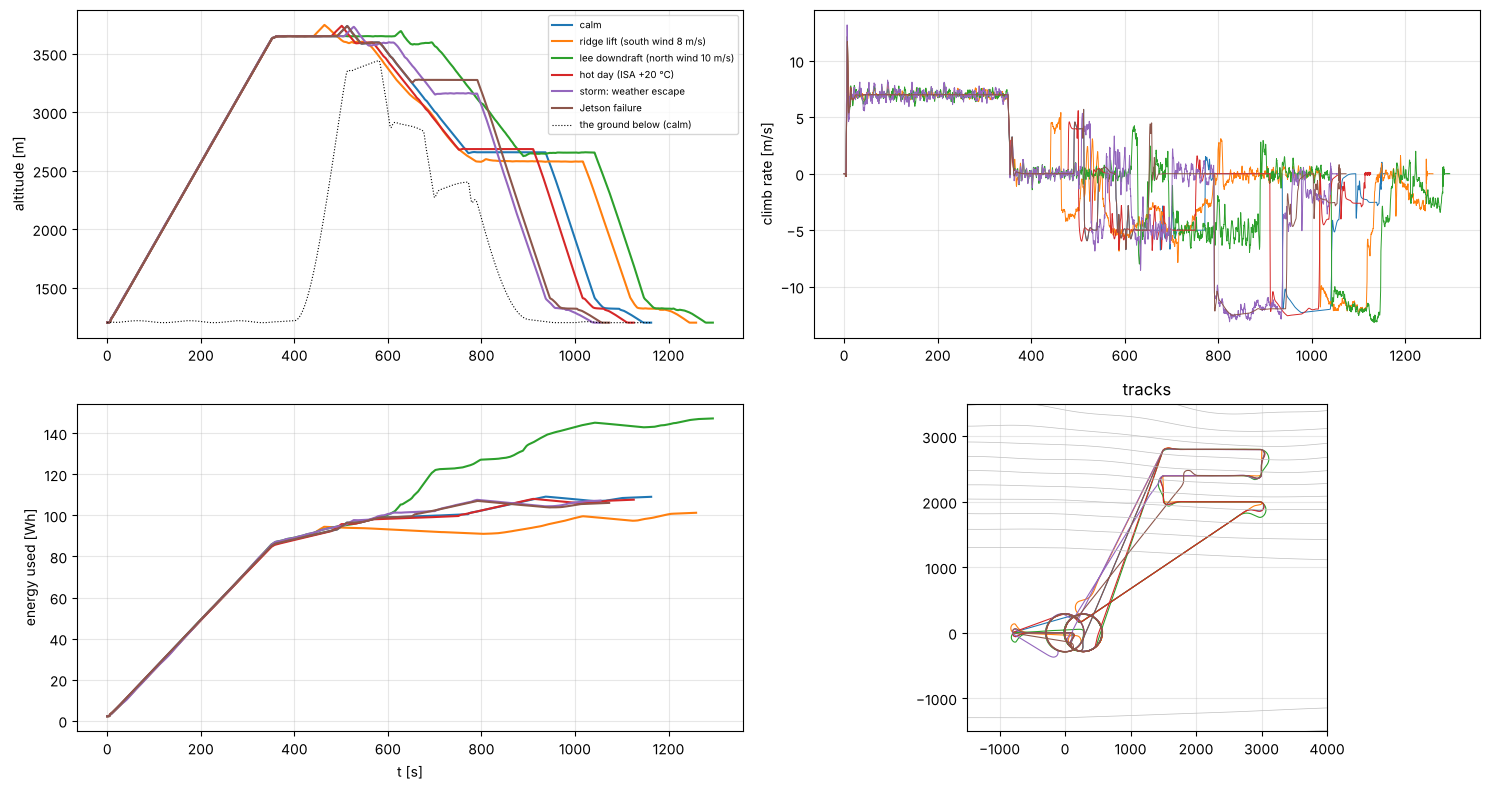

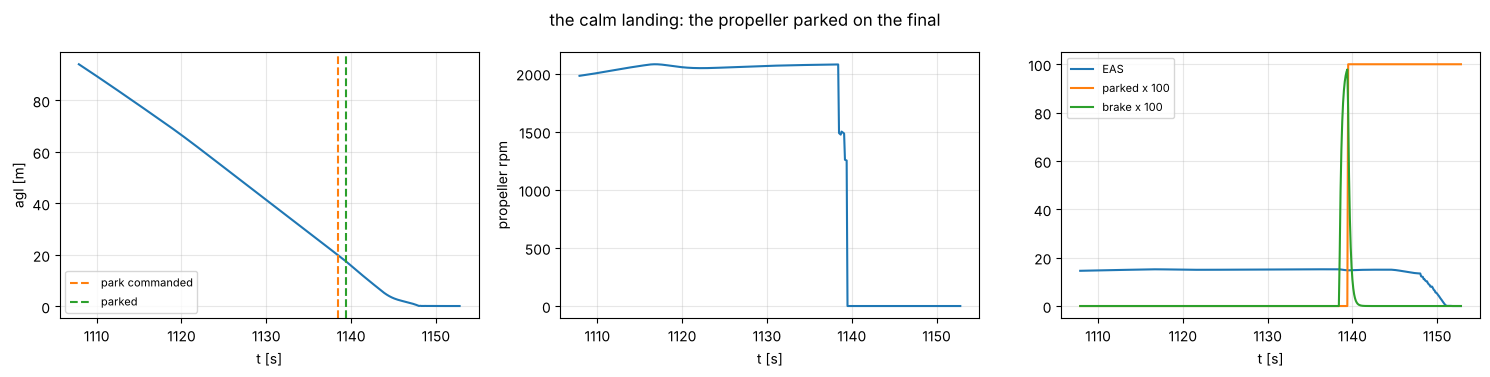

In [25]:
scn, ep = EPS[0]
display(save_table(fsc.phase_table(ep).round(2), f"phases_{scn.slug}"))
display(save_table(fsc.energy_table(ep).round(2), f"energy_{scn.slug}"))
fig, ax = plt.subplots(2, 2, figsize=(15, 8))
for scn_, ep_ in EPS:
    ts = fsc.timeseries(ep_)
    ax[0, 0].plot(ts["t"], ts["z_asl"], label=scn_.name)
    ax[0, 1].plot(ts["t"], ts["vz"], lw=0.7, label=scn_.name)
    ax[1, 0].plot(ts["t"], ts["E_used_Wh"], label=scn_.name)
    ax[1, 1].plot(ts["x"], ts["y"], lw=0.8, label=scn_.name)
ts = fsc.timeseries(EPS[0][1])
ax[0, 0].plot(ts["t"], ts["z_asl"] - ts["agl"], "k:", lw=0.8, label="the ground below (calm)")
ax[0, 0].set(ylabel="altitude [m]"); ax[0, 1].set(ylabel="climb rate [m/s]"); ax[1, 0].set(xlabel="t [s]", ylabel="energy used [Wh]")
ax[1, 1].contour(X, Y, M.height(X, Y), levels=np.arange(1500, 4400, 250), colors="0.75", linewidths=0.5); ax[1, 1].set_aspect("equal"); ax[1, 1].set(xlim=(-1500, 4000), ylim=(-1500, 3500), title="tracks")
for a in ax.flat: a.grid(alpha=0.3)
ax[0, 0].legend(fontsize=7)
fig.tight_layout(); fig.savefig(OUT / "plots" / "missions.png", dpi=110); plt.show()
# the last 40 s of the calm landing: the park command, the rpm, the height
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
td = ep.log["touchdown"] or ts["t"].iloc[-1]
w = ts[(ts["t"] > td - 40) & (ts["t"] < td + 5)]
ax[0].plot(w["t"], w["agl"]); ax[0].axvline(ep.log["t_park_cmd"], color="C1", ls="--", label="park commanded"); ax[0].axvline(ep.log["t_parked"] or td, color="C2", ls="--", label="parked"); ax[0].set(ylabel="agl [m]", xlabel="t [s]"); ax[0].legend(fontsize=8)
ax[1].plot(w["t"], w["rpm"]); ax[1].set(ylabel="propeller rpm", xlabel="t [s]")
ax[2].plot(w["t"], w["EAS"], label="EAS"); ax[2].plot(w["t"], 100 * w["parked"], label="parked x 100"); ax[2].plot(w["t"], 100 * w["brake"], label="brake x 100"); ax[2].set(xlabel="t [s]"); ax[2].legend(fontsize=8)
for a in ax: a.grid(alpha=0.3)
fig.suptitle("the calm landing: the propeller parked on the final"); fig.tight_layout(); fig.savefig(OUT / "plots" / "parking.png", dpi=110); plt.show()

In [26]:
MOVIES = []
for scn, ep in (EPS[:1] if QUICK else EPS):
    path = OUT / f"{scn.slug}.mp4"
    try:
        fsc.render_movie(ep, scn, path, speed=30.0, fps=20, size=(640, 360) if QUICK else (960, 540), progress=True)
        MOVIES.append(path); print("written", path)
    except Exception as e:
        print(f"{scn.label}: the movie needs pyvista off screen (xvfb-run): {type(e).__name__}: {e}")
if MOVIES:
    display(Video(str(MOVIES[0]), embed=False, width=800))

movie falco_calm: 0/773 |          | 00:00 

written output/35_falco/falco_calm.mp4


movie falco_ridge_lift_south_wind_8_ms: 0/837 |          | 00:00 

written output/35_falco/falco_ridge_lift_south_wind_8_ms.mp4


movie falco_lee_downdraft_north_wind_10_ms: 0/861 |          | 00:00 

...

written output/35_falco/falco_hot_day_ISA_20_C.mp4


movie falco_storm_weather_escape: 0/701 |          | 00:00 

written output/35_falco/falco_storm_weather_escape.mp4


movie falco_Jetson_failure: 0/713 |          | 00:00 

written output/35_falco/falco_Jetson_failure.mp4


## Part 11b — chasing birds over the slopes

NISUS+'s four hunts (notebook 33, Part 11b: golden eagles beating along the face in the ridge lift, griffon vultures
circling, the alpine chough flock, the eagles with the Jetson failing) on Falco-Zero. The camera sits in the chin under
the propeller's hub: the blades cross the top of the frame and computer vision masks them (an rpm-synchronous pattern) —
accepted, not modelled. The hunt ends with the propeller parked for the landing as in Part 11.

In [27]:
BSS = [fb.bird_scenarios()[0]] if QUICK else fb.bird_scenarios()
BEPS = []
for bs in tqdm(BSS, desc="bird hunts (MuJoCo + vegeta.mission)"):
    t0 = time.time()
    ep = fb.run(bs, log_geoms=True, progress=True)
    BEPS.append(ep)
    fb.photo_table(ep).to_csv(OUT / "tables" / f"{bs.slug}_photos.csv", index=False)
    print(f"{bs.name:34s} {ep.outcome['reason']:18s} ({time.time() - t0:.0f} s)")
BCMP = fb.compare(BEPS)
display(save_table(BCMP.T, "bird_hunts"))
display(fb.photo_table(BEPS[0]).head(15))

bird hunts (MuJoCo + vegeta.mission):   0%|          | 0/4 [00:00<?, ?it/s]

Falco-Zero — birds: golden eagles in the ridge lift: 0/1900 s |          | 00:00 

golden eagles in the ridge lift    landed             (219 s)


Falco-Zero — birds: griffon vultures circling: 0/1900 s |          | 00:00 

griffon vultures circling          landed             (170 s)


...

alpine chough flock                landed             (217 s)


Falco-Zero — birds: eagles, Jetson failure: 0/1900 s |          | 00:00 

eagles, Jetson failure             landed             (131 s)


scenario,golden eagles in the ridge lift,griffon vultures circling,alpine chough flock,"eagles, Jetson failure"
Jetson,Jetson Orin Nano Super 8 GB,Jetson Orin Nano Super 8 GB,Jetson Orin Nano Super 8 GB,Jetson Orin Nano Super 8 GB
model,YOLOX-Tiny,YOLOX-Tiny,YOLOX-Tiny,YOLOX-Tiny
lens,6 mm M12,6 mm M12,6 mm M12,6 mm M12
GPU load (assumed),0.32,0.32,0.32,0.32
search Hz,5.0,5.0,5.0,5.0
crop Hz,15.0,15.0,15.0,15.0
hunting [s],600.0,600.0,600.0,90.0
birds,3,5,9,3
photos,7,69,0,0
good photos,0,3,0,0


,t,track,bird,species,px_est,px_true,range_est,range_true,blur_true,centring_true,good_est,good_true
0,565.71,10,3,golden eagle,86.29,60.78,154.43,132.99,1.15,0.17,False,False
1,566.06,10,1,golden eagle,99.51,67.43,145.48,127.36,1.10,0.12,False,False
2,566.56,10,1,golden eagle,100.73,74.14,130.48,115.83,0.85,0.29,False,False
3,566.86,10,1,golden eagle,82.98,78.75,110.09,109.05,0.53,0.36,False,False
4,567.21,10,3,golden eagle,94.06,81.93,112.37,98.66,3.67,0.45,False,False
5,567.51,10,3,golden eagle,119.41,87.70,88.84,92.17,0.76,0.63,False,False
6,567.81,10,3,golden eagle,171.66,94.15,83.09,85.85,0.59,0.65,False,False


In [28]:
BMOVIES = []
for ep in BEPS[:1]:
    path = OUT / f"{ep.bird_scenario.slug}.mp4"
    try:
        fb.render_movie(ep, path, progress=True)
        BMOVIES.append(path); print("written", path)
    except Exception as e:
        print(f"the bird video needs pyvista off screen (xvfb-run): {type(e).__name__}: {e}")
if BMOVIES:
    display(Video(str(BMOVIES[0]), embed=False, width=900))

frame 0/1766


frame 200/1766


frame 400/1766


frame 600/1766


frame 800/1766


frame 1000/1766


frame 1200/1766


frame 1400/1766


frame 1600/1766


written output/35_falco/falco_birds_golden_eagles_in_the_ridge_lift.mp4


# Part 12 — the gain, the parked landing, the first recommended build

**The gain.** Against NISUS+ on the same mission (Part 9's table): the static thrust, the climb and the acceleration up
by the 20-inch disc, the cruise power down a little (the 20x15's efficiency against the longer body's drag), the
mission's energy down and the survey time up. The frame study's −11 % mission energy was with a motor of the AT4125's
loss class wound for the 20-inch propeller; the sourced AT5220's fitted resistance (0.13 Ω with the ESC) and its idle
current take part of it back — a lighter motor of that class with a published table (todo 5p.6) is the next step.

**The parked landing.** The propeller must be parked: a blade down is 150 mm in the meadow, and every mission above
lands with the blades horizontal — in the model, where the stop and the nudge take an assumed second. What is not
established: the ESC's brake-on-stop angle and the nudge's repeatability on the bench (todo 5p.4); until then a landing
with the blades not parked is the blade strike the judge names.

In [29]:
gain = CMPX["FALCO vs NISUS+ [%]"]
BUILD = pd.Series({
    "airframe": "2.4 m tractor, MERLIN's round fuselage (LW-PLA, FALCO-109), NISUS+'s three-piece wing with crow flaps and ailerons, one 30/28 roll-wrapped tail tube, a dorsal fin",
    "mass (8S3P)": f"{CI['8s3p-p45b']['mass_kg']:.2f} kg, CG 28 % MAC, wing loading {CI['8s3p-p45b']['wing_loading_N_m2']:.0f} N/m²",
    "drive": "T-Motor AT5220-A KV220 + APC 20x15E (fixed; parked for the landing), 80 A 8S AM32-class ESC with active braking, a Hall position sensor",
    "pack": f"8S3P Molicel P45B ({fs.pack().energy_wh:.0f} Wh, {fs.pack().mass_g:.0f} g) in an insulating sleeve",
    "computer": "Jetson Orin Nano Super on a 36 V-rated 12 V buck, IMX477 + 6 mm in the chin, LTE link; the DEM of the area onboard",
    "avionics": "H743-WING class, pitot-static airspeed (EAS) under the chin, lidar for the flare, ELRS 900 MHz, RFD900x",
    "launch / landing": "a light bungee (17 m/s) / a 9° crow approach, the propeller parked below 20 m, a belly landing on the keel",
    "climb (MTOW)": f"{ENV.loc['0 m', 'climb max [m/s]']:.1f} m/s at sea level, {ENV.loc['4500 m', 'climb max [m/s]']:.1f} m/s at 4500 m",
    "fast descent at 3000 m": f"{best.loc['crow + propeller brake', 'sink [m/s]']:.1f} m/s (crow + brake at {best.loc['crow + propeller brake', 'EAS [m/s]']:.0f} m/s EAS)",
    "mountain mission (Part 10)": f"{ME['E_used_wh']:.0f} Wh of {ME['E_available_wh']:.0f} available, {ME['E_left_pct_available']:.0f} % left, survey up to {ME['t_survey_feasible_s'] / 60:.0f} min",
    "against NISUS+": f"static thrust {gain['static thrust, sea level [N]']:+.0f} %, climb at 3000 m {gain['best climb at 3000 m [m/s]']:+.0f} %, cruise power at 3000 m {gain['cruise power 18 m/s EAS, 3000 m, battery side [W]']:+.0f} %, "
                      f"mission energy {gain['mission energy used [Wh]']:+.0f} %, survey time {gain['mission: feasible survey [min]']:+.0f} %",
}, name="the first recommended build")
display(BUILD.to_frame())

,the first recommended build
airframe,"2.4 m tractor, MERLIN's round fuselage (LW-PLA, FALCO-109), NISUS+'s three-piece wing with crow flaps and ..."
mass (8S3P),"5.35 kg, CG 28 % MAC, wing loading 87 N/m²"
drive,"T-Motor AT5220-A KV220 + APC 20x15E (fixed; parked for the landing), 80 A 8S AM32-class ESC with active br..."
pack,"8S3P Molicel P45B (389 Wh, 1814 g) in an insulating sleeve"
computer,"Jetson Orin Nano Super on a 36 V-rated 12 V buck, IMX477 + 6 mm in the chin, LTE link; the DEM of the area..."
avionics,"H743-WING class, pitot-static airspeed (EAS) under the chin, lidar for the flare, ELRS 900 MHz, RFD900x"
launch / landing,"a light bungee (17 m/s) / a 9° crow approach, the propeller parked below 20 m, a belly landing on the keel"
climb (MTOW),"12.7 m/s at sea level, 9.9 m/s at 4500 m"
fast descent at 3000 m,15.5 m/s (crow + brake at 22 m/s EAS)
mountain mission (Part 10),"177 Wh of 332 available, 47 % left, survey up to 45 min"


## Assumptions to refine next

- **The motor's point on the 20x15 at 8S**: the fit carries the 18x8's calibration to the 20-inch planform; a thrust
  stand run, and the real APC blade in Boreas.
- **The parking**: the ESC's brake-on-stop angle, the nudge, the Hall sensor, the companion script's timing against the
  20 m park height; the stop's duration (1 s assumed, no rotor inertia in the model).
- **The slipstream** over the fuselage and the wing root (drag, the tail's dynamic pressure at power, the pitot's
  reading): the CFD rotor-disk case, then flight tests.
- **Flutter at TAS** with the single tube: the roll-wrapped tube's G measured, Talos modes with the real G.
- **The fin's rod** at margin ~0.9 (10/8): a carbon plate fin would be lighter and stiffer.
- NISUS+'s own list: the brake region of the propeller, crow's drag, the Li-ion model in the cold, the mountain wind,
  the launch, the bird species, the terrain.

In [30]:
STATUS.update({"CAD": "run", "drawings": "run", "mass budgets": "run", "electronics": "run", "propulsion (sourced motor, drive options, propeller trade)": "run",
               "vortex lattice + crow + installation effects": "run", "mission energy": "run",
               "MuJoCo missions": f"run ({len(EPS)} scenarios, {sum(e.outcome['success'] for _, e in EPS)} landed, {sum(bool(e.log.get('parked_at_touchdown')) for _, e in EPS)} with the propeller parked)",
               "bird hunts": f"run ({len(BEPS)})", "movies": f"{len(MOVIES) + len(BMOVIES)} written"})
if DEBUG:
    STATUS["FEA"] = STATUS["CFD"] = "MOCKED (VEGETA_DEBUG): the numbers mean nothing"
display(pd.Series(STATUS, name="status").to_frame())

,status
CFD,NOT RUN
FEA,run
CAD,run
drawings,run
mass budgets,run
electronics,run
"propulsion (sourced motor, drive options, propeller trade)",run
vortex lattice + crow + installation effects,run
mission energy,run
MuJoCo missions,"run (6 scenarios, 6 landed, 6 with the propeller parked)"


In [31]:
def plain(x):
    if isinstance(x, (np.floating, float)):
        return None if not np.isfinite(x) else float(x)
    if isinstance(x, (np.integer,)):
        return int(x)
    if isinstance(x, (np.bool_,)):
        return bool(x)
    return x
DESIGN = {"source": "35_falco", "params": {k: plain(v) for k, v in P.items()}, "layout": {k: plain(v) for k, v in L.items() if not isinstance(v, dict)},
          "mass": {k: {kk: plain(x) for kk, x in c.items() if kk != "inertia"} for k, c in CI.items()},
          "derivatives": {k: plain(x) for k, x in DER["value"].items()}, "motor_fit": {k: plain(x) for k, x in FIT.items() if not isinstance(x, (str, dict))},
          "drive_options": {k: {kk: plain(vv) for kk, vv in row.items()} for k, row in DOPT.T.to_dict().items()},
          "propeller_trade": {k: {kk: plain(vv) for kk, vv in row.items()} for k, row in TRADE.T.to_dict().items()},
          "envelope": {h: {k: plain(x) for k, x in row.items()} for h, row in ENV.T.to_dict().items()},
          "mission_energy": {k: plain(ME[k]) for k in ("E_used_wh", "E_left_pct_available", "reserve_kept", "t_survey_feasible_s", "trigger_wh")},
          "nisus_plus_vs_falco": {k: {kk: plain(vv) for kk, vv in row.items()} for k, row in CMPX.T.to_dict().items()},
          "missions": {k: {kk: plain(vv) for kk, vv in row.items()} for k, row in CMP.T.to_dict().items()},
          "parking": {k: {kk: plain(vv) for kk, vv in row.items()} for k, row in fsc.park_table([e for _, e in EPS]).T.to_dict().items()},
          "fea": {k: {kk: plain(vv) for kk, vv in row.items()} for k, row in FEAT.T.to_dict().items()},
          "cfd": {k: {kk: plain(vv) for kk, vv in row.items()} for k, row in CFDT.T.to_dict().items()}, "status": STATUS}
target = OUT / "falco_design.json" if DEBUG else Path("designs/data/falco_design.json")
target.write_text(json.dumps(DESIGN, indent=1, default=str))
print("written", target)

written designs/data/falco_design.json
